In [1]:
import pandas as pd
import numpy as np
from zipfile import ZipFile
from pathlib import Path
import re
from io import BytesIO, TextIOWrapper
from tqdm import tqdm
from collections import defaultdict
from pathlib import Path
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.interpolate import griddata
from scipy import sparse
import math
import json
import time
import h5py
from pyproj import CRS, Transformer
import rasterio
from timezonefinder import TimezoneFinder
import pytz
from datetime import datetime, timedelta

import xarray as xr
import cdsapi
import zipfile
from dateutil.relativedelta import relativedelta
import dask
print(f"Dask is available! Version: {dask.__version__}")
import dask.array
import xdem
import time

Dask is available! Version: 2026.1.2


In [2]:
available_engines = xr.backends.list_engines()

print("Available Xarray engines:")
print(list(available_engines.keys()))

Available Xarray engines:
['h5netcdf', 'scipy', 'cfgrib', 'rasterio', 'store']


# Loading files

In [3]:
fire_growth_2024 = pd.read_csv('Fire growth points/Firegrowth_pts_v1_1_2024/Firegrowth_pts_v1_1_2024.csv')

In [4]:
def lonlat_to_canada_lambert(df, lon_col='lon', lat_col='lat'):
    """
    Convert lon/lat in EPSG:4269 (NAD83) to EPSG:3347 (NAD83 / Canada Lambert) in meters.
    Returns a copy of df with 'easting' and 'northing' columns and the target CRS object.
    """
    # Safety: require lon/lat columns
    if lon_col not in df.columns or lat_col not in df.columns:
        raise ValueError(f"DataFrame must contain columns '{lon_col}' and '{lat_col}'")

    source_crs = CRS.from_epsg(4269)   # NAD83 geographic (degrees)
    target_crs = CRS.from_epsg(3347)   # NAD83 / Canada Lambert (meters)

    transformer = Transformer.from_crs(source_crs, target_crs, always_xy=True)

    lons = df[lon_col].to_numpy(dtype=float)
    lats = df[lat_col].to_numpy(dtype=float)

    # transform (vectorized)
    eastings, northings = transformer.transform(lons, lats)

    df['easting'] = eastings
    df['northing'] = northings
    df.attrs['target_crs'] = target_crs.to_string()

    return df, target_crs

In [5]:
fire_growth_2024, used_crs = lonlat_to_canada_lambert(fire_growth_2024)

In [6]:
fire_growth_2024.head()

,ID,DOB,year,fireday,firearea,ecozone,fwi,isi,ffmc,dmc,...,aspect,cumuarea,pctgrowth,prevgrow,sprdistm,lon,lat,peat10,easting,northing
0,2024_1,225,2024,1,311.04,4.0,23.940081,10.384072,91.561157,31.728802,...,34.278625,311.04,0.0,0.0,1990.046301,-116.106160,60.100154,0,4.920918e+06,2.890838e+06
1,2024_1,225,2024,1,311.04,4.0,23.940081,10.384072,91.561157,31.728802,...,34.278625,311.04,0.0,0.0,1990.046301,-116.104586,60.100425,0,4.921008e+06,2.890834e+06
2,2024_1,225,2024,1,311.04,4.0,23.940081,10.384072,91.561157,31.728802,...,74.148155,311.04,0.0,0.0,1990.046301,-116.110339,60.098556,0,4.920644e+06,2.890762e+06
3,2024_1,225,2024,1,311.04,4.0,23.940081,10.384072,91.561157,31.728802,...,5.107979,311.04,0.0,0.0,1990.046301,-116.108765,60.098826,0,4.920734e+06,2.890757e+06
4,2024_1,225,2024,1,311.04,4.0,23.940081,10.384072,91.561157,31.728802,...,5.107979,311.04,0.0,0.0,1990.046301,-116.107191,60.099097,0,4.920824e+06,2.890753e+06


In [7]:
len(np.unique(fire_growth_2024['ID'].values))

372

In [8]:
fire_growth_2024.shape

(6240195, 63)

In [9]:
def summarize_fires(df, fire_ids, year=2024):
    """
    Summarizes fire growth data for a specific list of Fire IDs.
    Calculates total active days, spatial bounding boxes, and start/end months.
    """
    # Filter the DataFrame for the requested IDs
    filtered_df = df[df['ID'].isin(fire_ids)]
    
    if filtered_df.empty:
        print("None of the provided Fire IDs were found in the DataFrame.")
        return pd.DataFrame()
    
    summary_data = []
    
    # Group by Fire ID and calculate stats
    for fire_id, group in filtered_df.groupby('ID'):
        
        # Count unique fire days
        num_firedays = group['DOB'].nunique()
        
        # Spatial Bounding Box
        min_lon = group['lon'].min()
        max_lon = group['lon'].max()
        min_lat = group['lat'].min()
        max_lat = group['lat'].max()
        
        # Temporal bounds (Min and Max Day of Year)
        start_doy = group['DOB'].min()
        end_doy = group['DOB'].max()
        
        # Convert DOY to actual Date objects to extract the Month
        # (DOY 1 = Jan 1st, so we add DOY - 1 to Jan 1st of that year)
        start_date = datetime(year, 1, 1) + timedelta(days=int(start_doy) - 1)
        end_date = datetime(year, 1, 1) + timedelta(days=int(end_doy) - 1)
        
        # Extract month names (e.g., "July")
        start_month = start_date.strftime('%B')
        end_month = end_date.strftime('%B')
        
        # Append to our list
        summary_data.append({
            'Fire_ID': fire_id,
            'Total_FireDays': num_firedays,
            'Start_Month': start_month,
            'End_Month': end_month,
            'Min_Lon': min_lon,
            'Max_Lon': max_lon,
            'Min_Lat': min_lat,
            'Max_Lat': max_lat
        })
        
    return pd.DataFrame(summary_data)

In [10]:
target_ids = ['2024_188', '2024_306', '2024_486', '2024_545', '2024_560']
fire_summary_df = summarize_fires(fire_growth_2024, target_ids, year=2024)
fire_summary_df

,Fire_ID,Total_FireDays,Start_Month,End_Month,Min_Lon,Max_Lon,Min_Lat,Max_Lat
0,2024_188,35,July,August,-125.651308,-125.435873,58.148558,58.214093
1,2024_306,58,July,September,-97.333774,-96.973318,56.117143,56.260979
2,2024_486,11,March,April,-77.378256,-77.326635,45.908675,45.937873
3,2024_545,50,July,August,-79.164209,-78.726239,50.534639,50.767742
4,2024_560,2,June,June,-64.344006,-64.034503,51.495809,51.906273


In [11]:
processing_steps = [
    'file_creation', 
    'weather', 
    'topography', 
    'scanfi', 
    'vegetation'
]

time_tracker = {
    fire_id: {step: 0.0 for step in processing_steps} 
    for fire_id in target_ids
}

time_tracker

{'2024_188': {'file_creation': 0.0,
  'weather': 0.0,
  'topography': 0.0,
  'scanfi': 0.0,
  'vegetation': 0.0},
 '2024_306': {'file_creation': 0.0,
  'weather': 0.0,
  'topography': 0.0,
  'scanfi': 0.0,
  'vegetation': 0.0},
 '2024_486': {'file_creation': 0.0,
  'weather': 0.0,
  'topography': 0.0,
  'scanfi': 0.0,
  'vegetation': 0.0},
 '2024_545': {'file_creation': 0.0,
  'weather': 0.0,
  'topography': 0.0,
  'scanfi': 0.0,
  'vegetation': 0.0},
 '2024_560': {'file_creation': 0.0,
  'weather': 0.0,
  'topography': 0.0,
  'scanfi': 0.0,
  'vegetation': 0.0}}

In [12]:
timing_log_path = "fires_H5/processing_times.json"
with open(timing_log_path, "w") as f:
    json.dump(time_tracker, f, indent=4)

# Visualization functions

In [13]:
def plot_original_scatter(df, fire_id, lon_col="lon", lat_col="lat", area_col="firearea"):
    # Filter rows for the chosen fire
    df_fire = df[df["ID"] == fire_id]

    if df_fire.empty:
        print(f"No data found for fire_ID = {fire_id}")
        return

    plt.figure(figsize=(10,10))
    
    # Scatter plot
    plt.scatter(
        df_fire[lon_col],
        df_fire[lat_col],
        # s=1,
        s=30,
        marker='s',
        c=df_fire[area_col],
        cmap="viridis"
    )

    plt.colorbar(label="Fire Area")
    plt.xlabel(lon_col)
    plt.ylabel(lat_col)
    plt.title(f"Fire Area Scatter for Fire ID {fire_id}")
    plt.show()

In [14]:
def plot_original_scatter_by_day(df, fire_id, fireday,
                                 lon_col="lon", lat_col="lat", area_col="firearea"):
    # Filter all rows for this fire (all days)
    df_fire_full = df[df["ID"] == fire_id]

    if df_fire_full.empty:
        print(f"No data found for fire_ID = {fire_id}")
        return

    # Compute global bounds for the entire fire
    min_lon, max_lon = df_fire_full[lon_col].min(), df_fire_full[lon_col].max()
    min_lat, max_lat = df_fire_full[lat_col].min(), df_fire_full[lat_col].max()

    # Filter only the selected day
    df_fire_day = df_fire_full[df_fire_full["fireday"] == fireday]

    if df_fire_day.empty:
        print(f"No data found for fire_ID = {fire_id} on fireday {fireday}")
        return

    plt.figure(figsize=(10,10))

    plt.scatter(
        df_fire_day[lon_col],
        df_fire_day[lat_col],
        s=30,
        marker='s',
        c=df_fire_day[area_col],
        cmap="viridis"
    )

    # Fix the axis limits to full fire extent
    plt.xlim(min_lon, max_lon)
    plt.ylim(min_lat, max_lat)

    plt.colorbar(label="Fire Area")
    plt.xlabel(lon_col)
    plt.ylabel(lat_col)
    plt.title(f"Fire Area Scatter for Fire ID {fire_id}, Day {fireday}")
    plt.show()

In [15]:
def visualize_grid_values_by_image(grid, feature, fire_ID, fireday, patch):
    grid = np.asarray(grid)
    
    plt.figure(figsize=(7, 7))

    im = plt.imshow(grid, cmap='hot', origin='lower', interpolation='none')
    # cmap_ = plt.cm.RdYlGn.copy()
    # cmap_.set_bad(color='lightgray')
    # im = plt.imshow(grid, cmap=cmap_, origin='lower', interpolation='none')
    
    plt.title(f"{feature} - Fire {fire_ID} day {fireday} patch {patch}")
    plt.xlabel("x index")
    plt.ylabel("y index")
    
    plt.colorbar(im, fraction=0.046, pad=0.04)
    
    return im

In [16]:
def visualize_grid_values(grid, feature, fire_ID, fireday, patch, ax=None):
    grid = np.asarray(grid)
    rows, cols = np.where(~np.isnan(grid))
    values = grid[rows, cols]

    if ax is None:
        plt.figure(figsize=(7, 7))
        ax = plt.gca()
    
    sc = ax.scatter(cols, rows, c=values, cmap='hot', s=3)
    ax.set_title(f"{feature} - Fire {fire_ID} day {fireday} patch {patch}")
    ax.set_xlabel("x index")
    ax.set_ylabel("y index")
    return sc

In [17]:
def visualize_grid_features(features_list, features_grid, fire_ID, fireday, patch):
    n_features = len(features_list)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
    
    for idx, (channel, feature) in enumerate(enumerate(features_list)):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col] if n_rows > 1 else axes[col]
    
        sc = visualize_grid_values(
            # features_grid[..., channel],
            features_grid[channel],
            feature,
            fire_ID=fire_ID,
            fireday=fireday,
            patch=patch,
            ax=ax
        )
        plt.colorbar(sc, ax=ax)
    
    # Hide empty subplots
    for idx in range(n_features, n_rows*n_cols):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col] if n_rows > 1 else axes[col]
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

In [18]:
def visualize_grid_patches(patches, feature, fire_ID, fireday, subplot_width=5, subplot_height=5):
    
    num_patches = len(patches)
    
    if num_patches == 0:
        print("No patches to visualize.")
        return

    # Determine the grid layout
    cols = int(np.ceil(np.sqrt(num_patches)))
    rows = int(np.ceil(num_patches / cols))
    
    # Calculate total figure size based on desired individual subplot sizes
    total_width = subplot_width * cols
    total_height = subplot_height * rows
    
    # Create the figure with the exact calculated dimensions
    fig, axes = plt.subplots(rows, cols, figsize=(total_width, total_height))
    
    fig.suptitle(f"{feature} - Fire {fire_ID} Day {fireday}", fontsize=8, y=1.02)
    
    if num_patches == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, ax in enumerate(axes):
        if idx < num_patches:
            grid = np.asarray(patches[idx])
            im = ax.imshow(grid, cmap='hot', origin='lower', interpolation='none')
            
            ax.set_title(f"Patch {idx}")
            ax.set_xlabel("x index")
            ax.set_ylabel("y index")
            
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            ax.axis('off')
            
    plt.tight_layout()
    plt.show()

In [19]:
def visualize_spatial_grid_patches(patches, coords, feature, fire_ID, fireday, subplot_width=5, subplot_height=5):
    
    num_patches = len(patches)
    if num_patches == 0:
        print("No patches to visualize.")
        return

    # Find all the unique row (Y) and column (X) starting positions
    unique_ys = sorted(list(set(y for y, x in coords)))
    unique_xs = sorted(list(set(x for y, x in coords)))
    
    num_rows = len(unique_ys)
    num_cols = len(unique_xs)
    
    # Map smallest Y to the bottom row, largest Y to the top row
    row_idx_map = {y: (num_rows - 1 - i) for i, y in enumerate(unique_ys)}
    col_idx_map = {x: i for i, x in enumerate(unique_xs)}
    
    # Calculate total figure size based on desired individual subplot sizes
    total_width = subplot_width * num_cols
    total_height = subplot_height * num_rows
    
    # Create the figure with the exact calculated dimensions
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(total_width, total_height))
    fig.suptitle(f"{feature} - Fire {fire_ID} Day {fireday}", fontsize=12, y=1.02)
    
    # Handle single row/col edge cases safely to ensure axes is always 2D
    if num_rows == 1 and num_cols == 1:
        axes = np.array([[axes]])
    elif num_rows == 1:
        axes = axes[np.newaxis, :]
    elif num_cols == 1:
        axes = axes[:, np.newaxis]

    # Turn off all axes by default
    for ax in axes.flat:
        ax.axis('off')

    # Place every patch in its exact spatial location with your exact styling
    for idx, (patch, (y, x)) in enumerate(zip(patches, coords)):
        r = row_idx_map[y]
        c = col_idx_map[x]
        
        ax = axes[r, c]
        grid = np.asarray(patch)
        
        im = ax.imshow(grid, cmap='hot', origin='lower', interpolation='none')
        
        ax.set_title(f"Patch {idx} (Y:{y}, X:{x})")
        ax.set_xlabel("x index")
        ax.set_ylabel("y index")
        ax.axis('on')
        
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# Missing pixels

In [20]:
from timezonefinder import TimezoneFinder
import pytz
from datetime import datetime, timedelta
import h5py

In [21]:
H5_OUTPUT_FOLDER = "fires_H5"
BASE_FOLDER = Path('Fire growth points')
GRID_SIZE = 256
PIXEL_SIZE = 90
X_COL = 'easting'
Y_COL = 'northing'
os.makedirs(H5_OUTPUT_FOLDER, exist_ok=True)

In [22]:
subset_feature_list = ['ID', 'lon', 'lat', 'easting', 'northing', 'fireday', 'year', 'DOB', 'firearea', 'cumuarea', 'prec', 'tmax', 'ws', 'rh', 
                           'dem', 'slope', 'aspect', 
                           'Biomass', 'Closure', 'prcB', 'prcC']

In [23]:
def local_to_utc(row, tf, lon_col, lat_col):
    
    if pd.isna(row[lat_col]) or pd.isna(row[lon_col]) or pd.isna(row['DOB']):
        return pd.Series([None, None, None, None])
    
    tz_name = tf.timezone_at(lat=row[lat_col], lng=row[lon_col])

    if tz_name is None:
        tz_name = "UTC"

    tz = pytz.timezone(tz_name)

    date = datetime(int(row['year']), 1, 1) + timedelta(days=int(row['DOB'])-1)
    start_local = tz.localize(datetime(date.year, date.month, date.day))
    end_local = start_local + timedelta(days=1)
    noon_local = tz.localize(datetime(date.year, date.month, date.day, 12))

    return pd.Series([
        int(date.month),
        start_local.astimezone(pytz.utc).isoformat()[:19],
        end_local.astimezone(pytz.utc).isoformat()[:19],
        noon_local.astimezone(pytz.utc).isoformat()[:19]
    ])

In [24]:
def get_global_grid_params(df, fire_id, grid_size=256, pixel_size=90, x_col='easting', y_col='northing', min_overlap=0.1):
    
    fire_df = df[df["ID"] == fire_id]
    
    # Find the center of the entire fire's footprint
    x_center = fire_df[x_col].mean()
    y_center = fire_df[y_col].mean()

    # Determine how many pixels are needed to cover the footprint
    max_dist_x = max(abs(fire_df[x_col].max() - x_center), abs(fire_df[x_col].min() - x_center))
    max_dist_y = max(abs(fire_df[y_col].max() - y_center), abs(fire_df[y_col].min() - y_center))
    
    # Calculate base multipliers for your standard 256-grids
    mult_x = max(1, math.ceil((max_dist_x * 2) / (grid_size * pixel_size)))
    mult_y = max(1, math.ceil((max_dist_y * 2) / (grid_size * pixel_size)))
    
    base_grid_x = mult_x * grid_size
    base_grid_y = mult_y * grid_size

    # Calculate exact padding needed for the lowest overlap you plan to use
    stride = int(grid_size * (1.0 - min_overlap))
    
    def get_padding(base_dim):
        if base_dim <= grid_size:
            return 0  # A 1x1 grid (256x256) perfectly holds the center patch, no stepping needed
            
        dist_to_edge = (base_dim - grid_size) / 2.0
        remainder = dist_to_edge % stride
        
        if remainder == 0:
            return 0
        else:
            return int(stride - remainder)

    # Get the padding required PER SIDE
    pad_x = get_padding(base_grid_x)
    pad_y = get_padding(base_grid_y)

    # Add the padding symmetrically to both sides (pad * 2)
    final_grid_x = base_grid_x + (pad_x * 2)
    final_grid_y = base_grid_y + (pad_y * 2)

    # Define the Master Top-Left Origin using the newly padded dimensions
    x_min_ref = x_center - (final_grid_x * pixel_size) / 2
    y_max_ref = y_center + (final_grid_y * pixel_size) / 2
    
    return {
        "grid_size_x": final_grid_x,
        "grid_size_y": final_grid_y,
        "x_min_ref": x_min_ref,
        "y_max_ref": y_max_ref
    }

In [25]:
def initialize_fire_h5(output_folder, fire_id, year, params, pixel_size=90, fill_value=np.nan):
    file_path = os.path.join(output_folder, f"fire_{fire_id}.h5")
    
    grid_x_size = params["grid_size_x"]
    grid_y_size = params["grid_size_y"]
    x_min_ref = params["x_min_ref"]
    y_max_ref = params["y_max_ref"]

    # Initialize the transformer
    # always_xy=True ensures we use (Easting, Northing) -> (Lon, Lat) order
    transformer = Transformer.from_crs("EPSG:3347", "EPSG:4269", always_xy=True)

    with h5py.File(file_path, "w") as f:
        # Global Attributes
        f.attrs["fire_id"] = fire_id
        f.attrs["year"] = year
        f.attrs["pixel_size"] = pixel_size
        f.attrs["meter_crs"] = "EPSG:3347"
        f.attrs["deg_crs"] = "EPSG:4269"
        

        # Create Geometry Group
        geo = f.create_group("geometry")
        
        # Logic for 2D Grid
        res_rows, res_cols = np.indices((grid_y_size, grid_x_size))
        y_min_ref = y_max_ref - (grid_y_size * pixel_size)
        
        theoretical_x = x_min_ref + (res_cols * pixel_size)
        theoretical_y = y_min_ref + (res_rows * pixel_size)

        # Transforming the full 2D arrays
        theoretical_lon, theoretical_lat = transformer.transform(theoretical_x, theoretical_y)

        # Save Easting/Northing
        geo.create_dataset("theoretical_easting", data=theoretical_x, compression="gzip")
        geo.create_dataset("theoretical_northing", data=theoretical_y, compression="gzip")
        
        # Save Lon/Lat
        geo.create_dataset("theoretical_lon", data=theoretical_lon, compression="gzip")
        geo.create_dataset("theoretical_lat", data=theoretical_lat, compression="gzip")

        # Create Daily Group
        f.create_group("days")

    print(f"Initialized H5 for {fire_id} with geometry and coordinate transformation.")
    
    return file_path

In [26]:
def add_fire_day_to_h5(file_path, df, fire_id, fireday, params, pixel_size, 
                       fill_value=-9999, x_col='easting', y_col='northing', 
                       lat_col='lat', lon_col='lon'):
    
    # Features Columns
    env_cols = ['firearea', 'cumuarea']
    # Metadata
    meta_keys = ["DOB"]

    # Filter data for the specific fire and day
    df_day = df[(df["ID"] == fire_id) & (df["fireday"] == fireday)].copy()
    
    grid_x_size = params["grid_size_x"]
    grid_y_size = params["grid_size_y"]
    x_min_ref = params["x_min_ref"]
    y_max_ref = params["y_max_ref"]
    y_min_ref = y_max_ref - (grid_y_size * pixel_size)

    # Initialize Grids for observations and features
    # Coordinates (Observed)
    grid_obs_e = np.full((grid_y_size, grid_x_size), fill_value, dtype=np.float32)
    grid_obs_n = np.full((grid_y_size, grid_x_size), fill_value, dtype=np.float32)
    grid_obs_lat = np.full((grid_y_size, grid_x_size), fill_value, dtype=np.float32)
    grid_obs_lon = np.full((grid_y_size, grid_x_size), fill_value, dtype=np.float32)
    
    # Features
    env_grids = {col: np.full((grid_y_size, grid_x_size), fill_value, dtype=np.float32) for col in env_cols}

    # Map the Real Points onto the Grid
    if not df_day.empty:
        # Calculate pixel indices
        day_cols = np.round((df_day[x_col] - x_min_ref) / pixel_size).astype(int)
        day_rows = np.round((df_day[y_col] - y_min_ref) / pixel_size).astype(int)

        valid = (day_rows >= 0) & (day_rows < grid_y_size) & (day_cols >= 0) & (day_cols < grid_x_size)
        
        t_rows = day_rows[valid].values
        t_cols = day_cols[valid].values

        # Fill Coordinate Grids
        grid_obs_e[t_rows, t_cols] = df_day[x_col].values[valid]
        grid_obs_n[t_rows, t_cols] = df_day[y_col].values[valid]
        if lat_col in df_day.columns: grid_obs_lat[t_rows, t_cols] = df_day[lat_col].values[valid]
        if lon_col in df_day.columns: grid_obs_lon[t_rows, t_cols] = df_day[lon_col].values[valid]
        
        
        # Fill feature Columns
        for col in env_cols:
            if col in df_day.columns:
                env_grids[col][t_rows, t_cols] = df_day[col].values[valid]

    # Write to HDF5
    with h5py.File(file_path, "a") as f:
        # Create group for the day (e.g., /days/day_005)
        day_grp_name = f"days/day_{int(fireday):03d}"
        if day_grp_name in f: del f[day_grp_name] # Overwrite if exists
        
        day_grp = f.create_group(day_grp_name)
        
        # Add Metadata as Attributes
        day_grp.attrs["fireday"] = fireday
        
        if not df_day.empty:

            first_row = df_day.iloc[0] # Grab one representative point for this fire day
            
            # Calculate on the 
            timezone_finder = TimezoneFinder()
            month, start_utc, end_utc, noon_utc = local_to_utc(first_row, timezone_finder, lon_col, lat_col)
            
            # Save
            day_grp.attrs["month"] = month
            
            # Use isoformat() to turn datetimes into safe strings for H5
            day_grp.attrs["start_utc"] = start_utc.isoformat() if hasattr(start_utc, 'isoformat') else str(start_utc)
            day_grp.attrs["end_utc"]   = end_utc.isoformat()   if hasattr(end_utc, 'isoformat')   else str(end_utc)
            day_grp.attrs["noon_utc"]  = noon_utc.isoformat()  if hasattr(noon_utc, 'isoformat')  else str(noon_utc)

            
            for k in meta_keys:
                if k in df_day.columns:
                    val = df_day[k].iloc[0]
                    # Handle None or NaN for H5 attributes
                    day_grp.attrs[k] = val if pd.notnull(val) else "N/A"

        # Save Grids
        obs_grp = day_grp.create_group("observed_coords")
        obs_grp.create_dataset("easting", data=grid_obs_e, compression="gzip")
        obs_grp.create_dataset("northing", data=grid_obs_n, compression="gzip")
        obs_grp.create_dataset("lat", data=grid_obs_lat, compression="gzip")
        obs_grp.create_dataset("lon", data=grid_obs_lon, compression="gzip")
        
        env_grp = day_grp.create_group("features")
        for col, grid in env_grids.items():
            env_grp.create_dataset(col, data=grid, compression="gzip")

    # print(f"Added day {fireday} to {file_path}")

In [77]:
%%time

for folder in BASE_FOLDER.glob('Firegrowth_pts_v1_1_*'):

    year = folder.name.split('_')[-1]

    if year == '2024': # To be removed (instead from 2020 to 2024)
    
        csv_file = next(folder.glob('*.csv'))
            
        print(f"Loading data for year {year}: {csv_file.name}")
        
        # fire_growth_pts = pd.read_csv(csv_file)

        # for fire_id in fire_growth_pts['ID'].unique():
        for fire_id in tqdm(target_ids): # TO CHANGE

            # fire_df = fire_growth_pts[fire_growth_pts['ID'] == fire_id][subset_feature_list]
            fire_df = fire_growth_2024[fire_growth_2024['ID'] == fire_id][subset_feature_list] # TO CHANGE

            start_creation = time.time()
            
            grid_params = get_global_grid_params(fire_df, fire_id, GRID_SIZE, PIXEL_SIZE, X_COL, Y_COL)
            initialize_fire_h5(H5_OUTPUT_FOLDER, fire_id, year, grid_params, pixel_size=90, fill_value=np.nan)
            
            for fireday in sorted(fire_df['fireday'].unique()):

                add_fire_day_to_h5(f"{H5_OUTPUT_FOLDER}/fire_{fire_id}.h5", fire_df, fire_id, fireday, grid_params, pixel_size=90, 
                           fill_value=-9999, x_col='easting', y_col='northing', 
                           lat_col='lat', lon_col='lon')

            time_tracker[fire_id]['file_creation'] = time.time() - start_creation
            
            with open(timing_log_path, "w") as f:
                json.dump(time_tracker, f, indent=4)

Loading data for year 2024: Firegrowth_pts_v1_1_2024.csv


  0%|                                                                                            | 0/5 [00:00<?, ?it/s]

Initialized H5 for 2024_188 with geometry and coordinate transformation.


 20%|████████████████▊                                                                   | 1/5 [00:54<03:36, 54.06s/it]

Initialized H5 for 2024_306 with geometry and coordinate transformation.


...

Initialized H5 for 2024_545 with geometry and coordinate transformation.


 80%|███████████████████████████████████████████████████████████████████▏                | 4/5 [04:02<01:01, 61.60s/it]

Initialized H5 for 2024_560 with geometry and coordinate transformation.


100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [04:06<00:00, 49.38s/it]

CPU times: total: 3min 58s
Wall time: 4min 6s


In [27]:
def get_h5_attribute(file_path, attr_name, day=None):

    with h5py.File(file_path, "r") as f:
        # Case 1: Read from a specific day
        if day is not None:
            day_path = f"days/day_{int(day):03d}"
            if day_path in f:
                obj = f[day_path]
            else:
                return f"Error: Day {day} not found."
        
        # Case 2: Read from the root file level
        else:
            obj = f
            
        # Check if attribute exists
        if attr_name in obj.attrs:
            val = obj.attrs[attr_name]           
            
            return val
        else:
            return f"Error: Attribute '{attr_name}' not found at this level."

In [30]:
# get_h5_attribute(f"{H5_OUTPUT_FOLDER}/fire_2024_188.h5", "fire_id", day=None)
get_h5_attribute(f"{H5_OUTPUT_FOLDER}/fire_2024_188.h5", "noon_utc", day=6)

'2024-07-21T19:00:00'

In [82]:
get_h5_attribute(f"{H5_OUTPUT_FOLDER}/fire_2024_188.h5", "DOB", day=6)

np.int64(203)

In [83]:
def get_h5_dataset(file_path, dataset_path):
    """
    Reads a 2D grid from the H5 file.
    Example dataset_path: "days/day_001/features/Biomass"
    """
    with h5py.File(file_path, "r") as f:
        if dataset_path in f:
            return f[dataset_path][:]
        else:
            print(f"Path {dataset_path} not found.")
            return None

In [84]:
grid_from_h5 = get_h5_dataset(f"{H5_OUTPUT_FOLDER}/fire_2024_188.h5", "days/day_006/features/cumuarea")

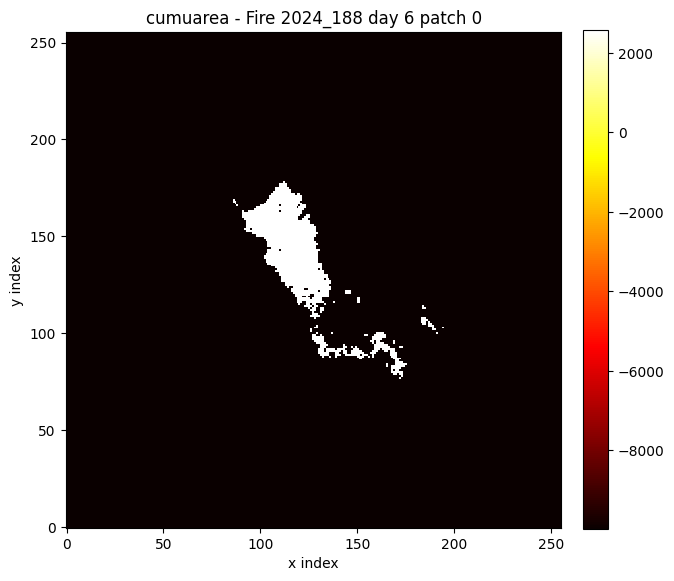

In [85]:
visualize_grid_values_by_image(grid_from_h5, feature='cumuarea', fire_ID='2024_188', fireday=6, patch=0)

# Weather Variables (ERA5)

In [31]:
from dateutil.relativedelta import relativedelta
import calendar

In [32]:
ERA5_FOLDER = 'ERA5'
os.makedirs(ERA5_FOLDER, exist_ok=True)

In [33]:
def process_era5_grid(ds_fire, lon_grid, lat_grid, day_attrs):

    # Times
    t_end = pd.to_datetime(day_attrs['end_utc'])
    p_end = pd.to_datetime(day_attrs['noon_utc']) + pd.Timedelta(hours=1)
    noon  = pd.to_datetime(day_attrs['noon_utc']) + pd.Timedelta(hours=1)
    
    # Selection for Noon variables (Wind, RH)
    noon_data = ds_fire.interp(
        latitude=xr.DataArray(lat_grid, dims=("y", "x")),
        longitude=xr.DataArray(lon_grid, dims=("y", "x")),
        valid_time=noon,
        method="nearest"
    )

    # Selection for Tmax and Prec
    tmax_data = ds_fire['t2m_24h_max'].interp(
        latitude=xr.DataArray(lat_grid, dims=("y", "x")),
        longitude=xr.DataArray(lon_grid, dims=("y", "x")),
        valid_time=t_end,
        method="nearest"
    )
    
    prec_data = ds_fire['tp_24h_sum'].interp(
        latitude=xr.DataArray(lat_grid, dims=("y", "x")),
        longitude=xr.DataArray(lon_grid, dims=("y", "x")),
        valid_time=p_end,
        method="nearest"
    )

    # Calculations
    u, v = noon_data['u10'].values, noon_data['v10'].values
    ws = np.sqrt(u**2 + v**2) * 3.6
    
    t_c = noon_data['t2m'].values - 273.15
    d_c = noon_data['d2m'].values - 273.15
    rh = 100 * (((112 - 0.1 * t_c + d_c) / (112 + 0.9 * t_c))**8)
    
    return {
        "ws": ws,
        "rh": rh,
        "tmax": tmax_data.values - 273.15,
        "prec": prec_data.values * 1000
    }

In [34]:
def fast_deduplicate_by_data(ds):

    # The objective of this function is to remove duplicates in the data when merging multiple months from ERA5
    # Example: Month 5 and Month 6 both contain data for the day 31-05 
    # However, in Month 6, the data only contains NaNs
    # So we remove based on the day that contains NaN (that is what call later the qulity score)

    
    # Create a 'quality score' (number of non-NaN values per timestamp)
    # We sum across space to see which hour is 'full'
    quality = (~ds['t2m'].isnull()).sum(dim=['latitude', 'longitude'])

    # Add this quality as a temporary coordinate
    ds = ds.assign_coords(quality=quality)
    
    # Sort by valid_time AND quality
    # This puts the timestamps with NaNs at the 'bottom' of each duplicate group
    ds = ds.sortby(['valid_time', 'quality'])
    
    # Drop duplicates, keeping the 'last' (which is the one with highest quality)
    ds = ds.drop_duplicates("valid_time", keep='last')
    
    return ds.drop_vars('quality')

In [35]:
def run_h5_era5_pipeline(h5_folder, era5_base_folder):
    
    h5_files = list(Path(h5_folder).glob("*.h5"))
    
    for h5_path in tqdm(h5_files):
        
        print(f"\n{'='*60}\nProcessing Fire H5: {h5_path.name}...")

        start_weather = time.time()
        
        with h5py.File(h5_path, "a") as f:
            
            # Get Geometry and Time Info
            lon_grid = f['geometry/theoretical_lon'][:]
            lat_grid = f['geometry/theoretical_lat'][:]

            fire_id = f.attrs['fire_id']
            
            # Collect all months present in this specific fire's days
            days_grp = f['days']
            fire_months = []
            fire_years = []
            
            for day_key in days_grp.keys():
                fire_months.append(int(days_grp[day_key].attrs['month']))
                fire_years.append(int(f.attrs['year'])) # Using global year attr

            
            required_months = []
            
            # Determine unique months from H5 attributes
            unique_months = sorted(set(int(f['days'][d].attrs['month']) for d in f['days'].keys()))
            y_int = int(f.attrs['year'])
            
            required_months = []
            for m_int in unique_months:
                
                required_months.append((y_int, m_int)) # Always add the current month
                
                # Filter days to ONLY this specific month
                days_this_month = [
                    pd.to_datetime(f['days'][d].attrs['noon_utc']) 
                    for d in f['days'].keys() 
                    if int(f['days'][d].attrs['month']) == m_int
                ]
                
                # If fire is on Day 1, add the PREVIOUS month for the 24h rolling window
                if any(d.day == 1 for d in days_this_month):
                    prev = datetime(y_int, m_int, 1) - relativedelta(months=1)
                    required_months.append((prev.year, prev.month))
                
                # If fire is on the Last Day, add the NEXT month for end_utc logic
                last_day_of_month = calendar.monthrange(y_int, m_int)[1]
                if any(d.day == last_day_of_month for d in days_this_month):
                    nxt = datetime(y_int, m_int, 1) + relativedelta(months=1)
                    required_months.append((nxt.year, nxt.month))
    
            # Deduplicate and sort
            required_months = sorted(list(set(required_months)))
    
            # fetch NCS
            required_ncs = []
            
            for y, m in required_months:
                nc_path = Path(era5_base_folder) / f"ERA5_LAND_{y}_{m}.nc"
                if nc_path.exists(): 
                    required_ncs.append(nc_path)
    
            print(f'Found {len(required_ncs)} nc files.')

            if not required_ncs:
                print(f"No NC file found for {h5_path.name}, skipping.")
                continue

            # Open and Process ERA5
            ds = xr.open_mfdataset(required_ncs, engine="h5netcdf", parallel=True)
            
            # Only load the box surrounding the fire with a buffer
            buffer = 0.1
            ds = ds.sel(latitude=slice(lat_grid.max() + buffer, lat_grid.min() - buffer),
                        longitude=slice(lon_grid.min() - buffer, lon_grid.max() + buffer))

            ds_indexed = fast_deduplicate_by_data(ds)
            print(f'Deduplicated.')

            # Rolling calculations
            tp_prev = ds_indexed['tp'].shift(valid_time=1)
            ds_indexed['tp_hourly'] = xr.where(
                (ds_indexed.valid_time.dt.hour == 1) | ((ds_indexed['tp'] - tp_prev) < -1e-7),
                ds_indexed['tp'],
                ds_indexed['tp'] - tp_prev
            )
            ds_indexed['t2m_24h_max'] = ds_indexed['t2m'].rolling(valid_time=24).max()
            ds_indexed['tp_24h_sum'] = ds_indexed['tp_hourly'].rolling(valid_time=24).sum()
            print(f'Temp and Prec calculated.')

            # Trigger the calculations
            print("Loading ERA5 slice into RAM...")
            start_bake = time.time()
            ds_indexed = ds_indexed.compute()
            print(f"Loading done in {time.time() - start_bake:.2f}s")

            # Save to H5
            for day_key in sorted(days_grp.keys()):
                
                day_grp = days_grp[day_key]
                day_attrs = dict(day_grp.attrs)
                
                # Process the theoretical Grid
                weather_v2 = process_era5_grid(ds_indexed, lon_grid, lat_grid, day_attrs)
                
                env_grp = day_grp['features']
                
                # Save
                for weather_dict in [weather_v2]:
                    for var_name, grid_data in weather_dict.items():
                        if var_name in env_grp:
                            env_grp[var_name][...] = grid_data
                        else:
                            env_grp.create_dataset(var_name, data=grid_data, compression="gzip")
            
            ds.close()
            ds_indexed.close()
            del ds, ds_indexed
            import gc
            gc.collect()
            
            print(f"Successfully processed {h5_path.name}")

        time_tracker[fire_id]['weather'] = time.time() - start_weather
        
        with open(timing_log_path, "w") as f:
            json.dump(time_tracker, f, indent=4)

In [95]:
%%time
run_h5_era5_pipeline(H5_OUTPUT_FOLDER, ERA5_FOLDER)

  0%|                                                                                            | 0/6 [00:00<?, ?it/s]


Processing Fire H5: fire_2024_188.h5...
Found 2 nc files.
Deduplicated.
Temp and Prec calculated.
Loading ERA5 slice into RAM...
Loading done in 6.37s


 17%|██████████████                                                                      | 1/6 [00:16<01:22, 16.55s/it]

Successfully processed fire_2024_188.h5
Skipping Fire H5: fire_2024_188_temp.h5.

Processing Fire H5: fire_2024_306.h5...
Found 3 nc files.
Deduplicated.
Temp and Prec calculated.
Loading ERA5 slice into RAM...
Loading done in 9.39s


 50%|██████████████████████████████████████████                                          | 3/6 [00:40<00:39, 13.26s/it]

...

Successfully processed fire_2024_486.h5

Processing Fire H5: fire_2024_545.h5...
Found 2 nc files.
Deduplicated.
Temp and Prec calculated.
Loading ERA5 slice into RAM...
Loading done in 6.44s


 83%|██████████████████████████████████████████████████████████████████████              | 5/6 [01:48<00:27, 27.02s/it]

Successfully processed fire_2024_545.h5

Processing Fire H5: fire_2024_560.h5...
Found 1 nc files.
Deduplicated.
Temp and Prec calculated.
Loading ERA5 slice into RAM...
Loading done in 2.80s


100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:53<00:00, 18.88s/it]

Successfully processed fire_2024_560.h5
CPU times: total: 1min 57s
Wall time: 1min 53s


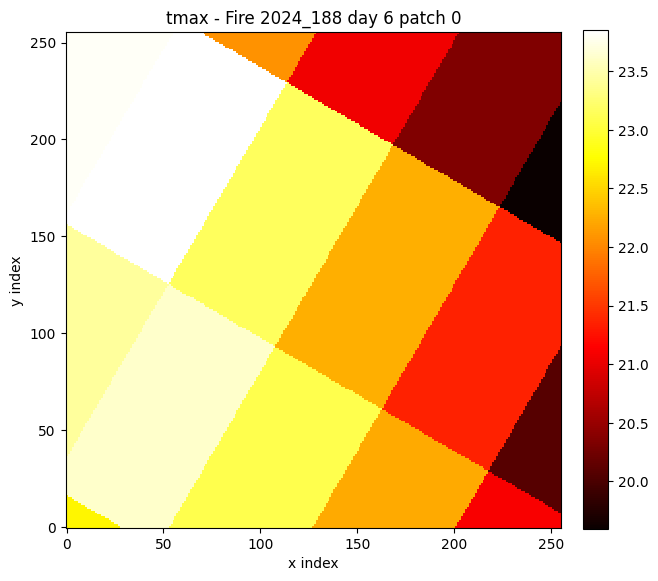

In [96]:
grid_from_h5 = get_h5_dataset(f"{H5_OUTPUT_FOLDER}/fire_2024_188.h5", "days/day_006/features/tmax")
visualize_grid_values_by_image(grid_from_h5, feature='tmax', fire_ID='2024_188', fireday=6, patch=0)

# Vegetation (SCANFI)

In [36]:
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import from_bounds
import rioxarray
from rasterio.windows import Window
from rasterio.windows import from_bounds
from pyproj import Transformer
from scipy import stats
import xarray as xr

In [37]:
SCANFI_FOLDER = 'SCANFI'
os.makedirs(SCANFI_FOLDER, exist_ok=True)

SCANFI_VARS = {
    'Biomass': 'SCANFI_att_biomass_SW',
    'Closure': 'SCANFI_att_closure_SW',
    'prcC': 'SCANFI_sps_prcC_other_SW',
    'prcB': 'SCANFI_sps_prcB_SW'
}
SCANFI_KEYWORDS = ['biomass', 'closure', 'prcC', 'prcB']

## Static Extraction

In [38]:
def extract_scanfi_for_grid(tif_path, lon_grid, lat_grid):
    """
    Extracts 2D grid data from a large TIFF file efficiently by cropping first.
    """
    with rioxarray.open_rasterio(tif_path) as da:
        
        # Setup Transformer
        transformer = Transformer.from_crs("EPSG:4269", da.rio.crs, always_xy=True)
        
        # Transform the entire 2D grid to the Raster's CRS
        target_x, target_y = transformer.transform(lon_grid, lat_grid)
        
        # Crop the raster to the fire's extent
        # Add a 200m buffer
        buffer = 200
        min_x, max_x = target_x.min() - buffer, target_x.max() + buffer
        min_y, max_y = target_y.min() - buffer, target_y.max() + buffer
        
        da_cropped = da.rio.clip_box(minx=min_x, miny=min_y, maxx=max_x, maxy=max_y)
        
        # Create 2D Xarray coordinates
        x_coords = xr.DataArray(target_x, dims=("y", "x"))
        y_coords = xr.DataArray(target_y, dims=("y", "x"))
        
        # Sample the cropped raster at the grid points
        sampled = da_cropped.sel(x=x_coords, y=y_coords, method="nearest").compute()
        
        # Extract the numpy array
        if sampled.ndim == 3 and sampled.shape[0] == 1:
            return sampled.values[0]
        
        return sampled.values

In [39]:
def run_static_scanfi_pipeline(h5_folder, scanfi_folder, current_year="2020"):
    
    h5_files = list(Path(h5_folder).glob("*.h5"))
    
    year_folder = Path(scanfi_folder) / current_year
    
    for h5_path in tqdm(h5_files):
            
        print(f"\n{'='*60}\nProcessing Static SCANFI for: {h5_path.name}")

        start_scanfi = time.time()
        
        with h5py.File(h5_path, "a") as f:
            
            # Get coordinates
            lon_grid = f['geometry/theoretical_lon'][:]
            lat_grid = f['geometry/theoretical_lat'][:]

            fire_id = f.attrs['fire_id']
            
            # Create static features bloc if not existing
            if 'static_features' not in f:
                static_grp = f.create_group('static_features')
            else:
                static_grp = f['static_features']
            
            # Loop on SCANFI variables
            for key, file_prefix in SCANFI_VARS.items():
                
                var_name = key.lower()  # e.g., 'biomass'
                
                # Fetch the SCANFI rasters
                matching_files = list(year_folder.glob(f"*{file_prefix}*_90m_v2.tif"))
                
                if not matching_files:
                    print(f"Skipping {var_name}: No TIF found matching '{file_prefix}'.")
                    continue
                
                tif_path = matching_files[0]
                
                # # Check already processed
                # if var_name in static_grp:
                #     print(f"Already have {var_name}, skipping.")
                #     continue
                    
                print(f"Extracting {var_name} from {tif_path.name}...")
                
                # Fetch the 2D array
                grid_data = extract_scanfi_for_grid(tif_path, lon_grid, lat_grid)
                
                # Save to HDF5
                static_grp.create_dataset(var_name, data=grid_data, compression="lzf")
                
                print(f"Saved {var_name}.")

        time_tracker[fire_id]['scanfi'] = time.time() - start_scanfi
        
        with open(timing_log_path, "w") as f:
            json.dump(time_tracker, f, indent=4)

## SCANFI Tests

In [120]:
run_static_scanfi_pipeline(H5_OUTPUT_FOLDER, f"{SCANFI_FOLDER}", current_year="2020")

  0%|                                                                                            | 0/6 [00:00<?, ?it/s]


Skipping Fire H5: fire_2024_188.h5...

Skipping Fire H5: fire_2024_188_temp.h5...

Processing Static SCANFI for: fire_2024_306.h5
Extracting biomass from SCANFI_att_biomass_SW_2020_90m_v2.tif...
Saved biomass.
Extracting closure from SCANFI_att_closure_SW_2020_90m_v2.tif...
Saved closure.
Extracting prcc from SCANFI_sps_prcC_other_SW_2020_90m_v2.tif...


 50%|██████████████████████████████████████████                                          | 3/6 [00:00<00:00,  3.97it/s]

Saved prcc.
Extracting prcb from SCANFI_sps_prcB_SW_2020_90m_v2.tif...
Saved prcb.

Processing Static SCANFI for: fire_2024_486.h5
Extracting biomass from SCANFI_att_biomass_SW_2020_90m_v2.tif...
Saved biomass.
Extracting closure from SCANFI_att_closure_SW_2020_90m_v2.tif...
Saved closure.
Extracting prcc from SCANFI_sps_prcC_other_SW_2020_90m_v2.tif...
Saved prcc.
Extracting prcb from SCANFI_sps_prcB_SW_2020_90m_v2.tif...


 67%|████████████████████████████████████████████████████████                            | 4/6 [00:01<00:00,  2.38it/s]

Saved prcb.

Processing Static SCANFI for: fire_2024_545.h5
Extracting biomass from SCANFI_att_biomass_SW_2020_90m_v2.tif...
Saved biomass.
Extracting closure from SCANFI_att_closure_SW_2020_90m_v2.tif...
Saved closure.
Extracting prcc from SCANFI_sps_prcC_other_SW_2020_90m_v2.tif...
Saved prcc.
Extracting prcb from SCANFI_sps_prcB_SW_2020_90m_v2.tif...


 83%|██████████████████████████████████████████████████████████████████████              | 5/6 [00:04<00:01,  1.24s/it]

Saved prcb.

Processing Static SCANFI for: fire_2024_560.h5
Extracting biomass from SCANFI_att_biomass_SW_2020_90m_v2.tif...
Saved biomass.
Extracting closure from SCANFI_att_closure_SW_2020_90m_v2.tif...
Saved closure.
Extracting prcc from SCANFI_sps_prcC_other_SW_2020_90m_v2.tif...
Saved prcc.
Extracting prcb from SCANFI_sps_prcB_SW_2020_90m_v2.tif...


100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:06<00:00,  1.09s/it]

Saved prcb.


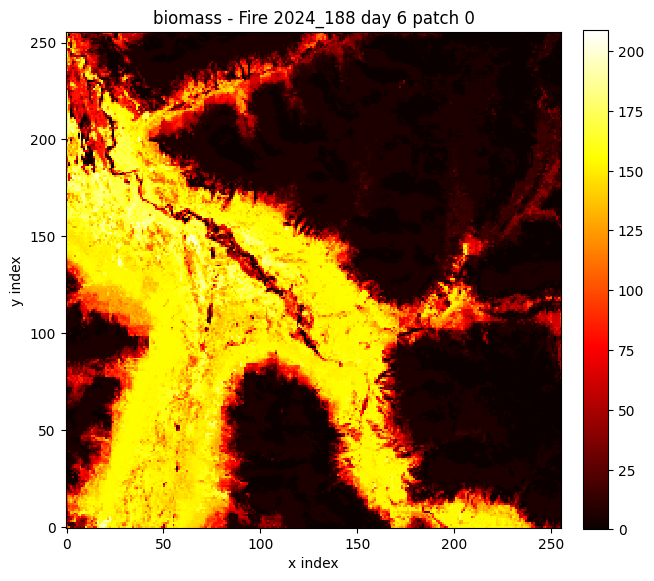

In [122]:
grid_from_h5_biomass = get_h5_dataset(f"{H5_OUTPUT_FOLDER}/fire_2024_188.h5", "static_features/biomass")
visualize_grid_values_by_image(grid_from_h5_biomass, feature='biomass', fire_ID='2024_188', fireday=6, patch=0)

# Topography

In [40]:
import rasterio
from rasterio.coords import BoundingBox
import json
from copy import deepcopy
import requests
import getpass, pprint, time, os
import xarray as xr
from pathlib import Path
from pyproj import Transformer
import re
import xdem
import rioxarray
from rioxarray.merge import merge_arrays

In [50]:
DEM_FOLDER = Path('DEM_API')
DEM_FOLDER.mkdir(parents=True, exist_ok=True)

In [51]:
TOPO_VARS = {
    'dem_avg': f"{DEM_FOLDER}/Elevation_avg",
    'slope': f"{DEM_FOLDER}/Slope",
    'aspect': f"{DEM_FOLDER}/Aspect"
}
TOPO_VARS

{'dem_avg': 'DEM_API/Elevation_avg',
 'slope': 'DEM_API/Slope',
 'aspect': 'DEM_API/Aspect'}

In [44]:
def get_tiles(fire_id, raster_folder):
    """
    Retrieves the specific terrain tile(s) for a given fire ID from a folder.
    """
    # Use glob to find any .tif file that starts with the fire_id
    # e.g., "2024_545_*.tif"
    overlapping = list(Path(raster_folder).glob(f"{fire_id}_*.tif"))
    
    return overlapping

In [49]:
get_tiles(fire_id='2024_188', raster_folder=TOPO_VARS['slope'])

[WindowsPath('../DEM_API/Slope/2024_188_slope_90m.tif')]

In [52]:
def get_cropped_mosaic(tile_paths, target_x, target_y, is_latlon=True):
    
    """Opens, crops, masks NoData, and merges multiple raster tiles using pre-matched grids."""
    cropped_das = []
    
    # if is_latlon:
    #     buffer = 0.05  # Degrees
    # else:
    #     buffer = 1000000  # Meters
    buffer = 0
        
    # Get the bounding box directly from the grid you passed in
    min_x, max_x = target_x.min() - buffer, target_x.max() + buffer
    min_y, max_y = target_y.min() - buffer, target_y.max() + buffer

    with rioxarray.open_rasterio(tile_paths[0]) as da: 
        nodata_value = da.rio.nodata
    
    for path in tile_paths:
        
        with rioxarray.open_rasterio(path, masked=True) as da: 
            
            try:
                # Crop immediately using the pre-calculated min/max
                da_cropped = da.rio.clip_box(minx=min_x, miny=min_y, maxx=max_x, maxy=max_y)
                
                # Mask out any remaining NoData
                da_cropped = da_cropped.where(da_cropped != nodata_value)
                
                cropped_das.append(da_cropped)
            
            except Exception:
                # Bbox misses this tile, safely ignore
                pass 
                
    if not cropped_das: 
        return None
    
    if len(cropped_das) == 1: 
        return cropped_das[0].fillna(nodata_value)
        
    # Merge and fill
    mosaic = merge_arrays(cropped_das)
    
    mosaic = mosaic.fillna(nodata_value)
    
    return mosaic

In [53]:
def run_static_topography_pipeline(h5_path, dem_folders_dict):
    
    print(f"\n{'='*60}\nRunning Static Topography for: {Path(h5_path).name}")

    start_topography = time.time()
    
    with h5py.File(h5_path, "a") as f:
        
        # Get theoretical grid
        lon_grid = f['geometry/theoretical_lon'][:]
        lat_grid = f['geometry/theoretical_lat'][:]

        # Get theoretical grid
        easting_grid = f['geometry/theoretical_easting'][:]
        northing_grid = f['geometry/theoretical_northing'][:]

        fire_id = f.attrs['fire_id']
        
        min_lon, max_lon = lon_grid.min(), lon_grid.max()
        min_lat, max_lat = lat_grid.min(), lat_grid.max()
        
        # Ensure static group exists
        static_grp = f.require_group('static_features')
            
        for var_name, folder_path in dem_folders_dict.items():
            
            var_v2 = f"{var_name}"

            tiles = get_tiles(fire_id, folder_path)
            
            if not tiles:
                print(f"Skipping {var_v2}: No tiles found.")
                continue
            
            print(f"Extracting {var_v2}...")
            if var_name == 'dem_avg' or var_name == 'dem':
                da_mosaic = get_cropped_mosaic(tiles, lon_grid, lat_grid, is_latlon=True)
            else:
                da_mosaic = get_cropped_mosaic(tiles, easting_grid, northing_grid, is_latlon=False)
            
            if da_mosaic is None:
                continue
                
            transformer = Transformer.from_crs("EPSG:4269", da_mosaic.rio.crs, always_xy=True)
            target_x, target_y = transformer.transform(lon_grid, lat_grid)
            
            x_coords = xr.DataArray(target_x, dims=("y", "x"))
            y_coords = xr.DataArray(target_y, dims=("y", "x"))
            
            # Sample the continuous grid
            v2_sampled = da_mosaic.sel(x=x_coords, y=y_coords, method="nearest").compute()
            v2_data = v2_sampled.values[0] if v2_sampled.ndim == 3 else v2_sampled.values
            
            # Save to static_features
            if var_v2 in static_grp:
                static_grp[var_v2][...] = v2_data
            else:
                static_grp.create_dataset(var_v2, data=v2_data, compression="lzf")

    time_tracker[fire_id]['topography'] = time.time() - start_topography
    
    with open(timing_log_path, "w") as f:
        json.dump(time_tracker, f, indent=4)
                
    print(f"Finished saving static topography to {Path(h5_path).name}.")

In [137]:
h5_files = list(Path(H5_OUTPUT_FOLDER).glob("*.h5"))
    
for h5_path in tqdm(h5_files):
    run_static_topography_pipeline(h5_path, TOPO_VARS)

  0%|                                                                                            | 0/6 [00:00<?, ?it/s]


Running Static Topography for: fire_2024_188.h5
Extracting dem_avg...
Extracting slope...
Extracting aspect...


 17%|██████████████                                                                      | 1/6 [00:00<00:02,  1.90it/s]

Finished saving static topography to fire_2024_188.h5.

Running Static Topography for: fire_2024_188_temp.h5
Extracting dem_avg...
Extracting slope...


 33%|████████████████████████████                                                        | 2/6 [00:00<00:01,  2.04it/s]

...

Extracting aspect...
Finished saving static topography to fire_2024_486.h5.

Running Static Topography for: fire_2024_545.h5
Extracting dem_avg...
Extracting slope...
Extracting aspect...


 83%|██████████████████████████████████████████████████████████████████████              | 5/6 [00:03<00:01,  1.02s/it]

Finished saving static topography to fire_2024_545.h5.

Running Static Topography for: fire_2024_560.h5
Extracting dem_avg...
Extracting slope...
Extracting aspect...


100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.15it/s]

Finished saving static topography to fire_2024_560.h5.


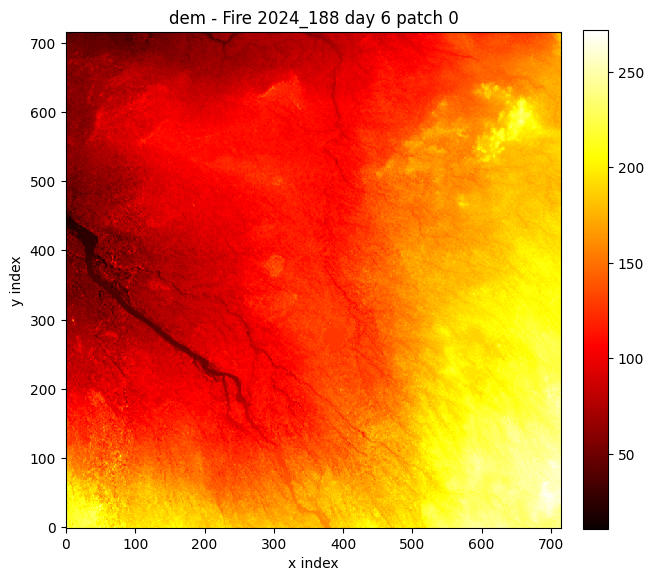

In [138]:
grid_from_h5 = get_h5_dataset(f"{H5_OUTPUT_FOLDER}/fire_2024_545.h5", "static_features/dem_avg")
visualize_grid_values_by_image(grid_from_h5, feature='dem', fire_ID='2024_188', fireday=6, patch=0)

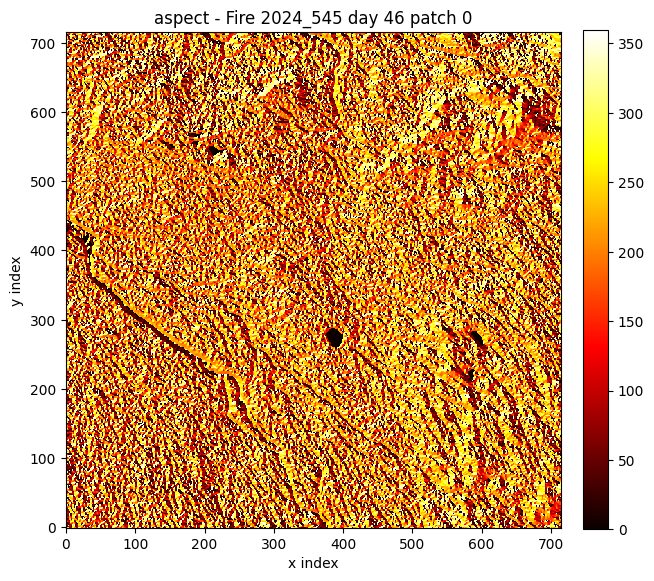

In [139]:
static_feature = 'aspect'
grid_from_h5 = get_h5_dataset(f"{H5_OUTPUT_FOLDER}/fire_2024_545.h5", f"static_features/{static_feature}")
visualize_grid_values_by_image(grid_from_h5, feature=static_feature, fire_ID='2024_545', fireday=46, patch=0)

In [140]:
grid_from_h5.min(), grid_from_h5.max()

(np.float64(0.0), np.float64(359.454345703125))

# Vegetation (VIIRS - GEE)

In [54]:
import ee
from timezonefinder import TimezoneFinder
import pytz
from datetime import datetime, timedelta
import time
import requests
import rasterio
from rasterio.io import MemoryFile
import rioxarray
import xarray as xr
from tqdm import tqdm
import datetime
import traceback

In [55]:
try:
    ee.Initialize(project='widlfires-vegetation')
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='widlfires-vegetation')

In [56]:
def get_gee_url_with_retry(ee_image, roi, max_retries=5):
    """
    Requests a download URL from GEE with exponential backoff.
    Injects the exact EPSG:4326 grid transform for perfect pixel alignment.
    """
    wait_time = 2
    
    for attempt in range(max_retries):
        try:
            url = ee_image.getDownloadURL({
                'crs': 'EPSG:4326', 
                'crs_transform': [0.004166666666666667, 0, -141.0, 
                                  0, -0.004166666666666667, 83.0],
                'region': roi,
                'format': 'GEO_TIFF'
            })
            return url
            
        except ee.EEException as e:
            error_msg = str(e).lower()
            if "too many" in error_msg or "capacity" in error_msg or "quota" in error_msg:
                print(f"GEE busy. Retrying in {wait_time}s (Attempt {attempt+1}/{max_retries})...")
                time.sleep(wait_time)
                wait_time *= 2  
            else:
                raise e
                
    print("Failed to get GEE URL after max retries.")
    
    return None

In [57]:
def fetch_in_memory_raster(url):
    """
    Downloads GeoTIFF bytes and loads them into rioxarray in RAM.
    """
    response = requests.get(url)
    if response.status_code != 200:
        print(f"HTTP Error {response.status_code} during download.")
        return None, None, None
        
    memfile = MemoryFile(response.content)
    src = memfile.open()
    da = rioxarray.open_rasterio(src)
    return da, memfile, src

In [58]:
def run_daily_viirs_pipeline(h5_path):
    """
    Extracts dynamic NDVI and EVI for each day directly into RAM,
    fetching the composite from strictly before the current fire day.
    """
    fire_name = Path(h5_path).stem
    print(f"\n{'='*60}\nRunning Daily VIIRS Pipeline for: {fire_name}")
    
    with h5py.File(h5_path, "a") as f:
        # Geometry Setup
        lon_grid = f['geometry/theoretical_lon'][:]
        lat_grid = f['geometry/theoretical_lat'][:]
        
        buffer = 0.05
        min_lon, max_lon = lon_grid.min() - buffer, lon_grid.max() + buffer
        min_lat, max_lat = lat_grid.min() - buffer, lat_grid.max() + buffer
        roi = ee.Geometry.Rectangle([min_lon, min_lat, max_lon, max_lat])
        
        x_coords = xr.DataArray(lon_grid, dims=("y", "x"))
        y_coords = xr.DataArray(lat_grid, dims=("y", "x"))
        
        days_grp = f['days']
        day_keys = sorted(days_grp.keys())
        if not day_keys: return

        # Time Window Calculation
        fire_year = int(f.attrs['year'])
        first_doy = int(days_grp[day_keys[0]].attrs['DOB'])
        last_doy  = int(days_grp[day_keys[-1]].attrs['DOB'])
        
        # Buffer the start date backward by 33 days to catch the previous 16-day composites
        start_date_ee = ee.Date.fromYMD(fire_year, 1, 1).advance(first_doy - 33, 'day')
        end_date_ee = ee.Date.fromYMD(fire_year, 1, 1).advance(last_doy, 'day')

        # Pre-fetch VIIRS composite timestamps (1 API Call)
        print("Fetching VIIRS composite schedule...")
        viirs_times_ms = ee.ImageCollection("NASA/VIIRS/002/VNP13A1") \
            .filterDate(start_date_ee, end_date_ee) \
            .aggregate_array('system:time_start') \
            .getInfo()
            
        viirs_times_ms = sorted(viirs_times_ms)
        
        # Cache locks
        cached_time_ms = None
        da_ndvi = None
        da_evi = None
        memfile = None
        src = None

        # Loop through Fire Days
        for day_key in day_keys:
            
            day_grp = days_grp[day_key]
            env_grp = day_grp.require_group('features')

            # Calculate the exact timestamp threshold using daily attribute
            current_doy = int(day_grp.attrs['DOB'])
            current_date_py = datetime.datetime(fire_year, 1, 1, tzinfo=datetime.timezone.utc) + datetime.timedelta(days=current_doy - 1)
            target_limit_ms = int(current_date_py.timestamp() * 1000)
            
            # Find the most recent VIIRS image strictly before this day
            valid_times = [t for t in viirs_times_ms if t < target_limit_ms]
            if not valid_times:
                print(f"  -> No prior VIIRS image found for {day_key}, skipping...")
                continue
                
            target_time_ms = valid_times[-1]

            # The GEE Request Block (Only triggers if the 16-day window shifted)
            if target_time_ms != cached_time_ms:
                if memfile: 
                    src.close()
                    memfile.close() # Flush old TIFF from RAM
                
                # Ask GEE for the exact composite
                img = (ee.ImageCollection("NASA/VIIRS/002/VNP13A1")
                        .filter(ee.Filter.eq('system:time_start', target_time_ms))
                        .select(['NDVI', 'EVI'])
                        .first()
                        .clip(roi))
                
                url = get_gee_url_with_retry(img, roi)
                if not url: continue
                
                da, memfile, src = fetch_in_memory_raster(url)
                if da is None: continue
                
                # Select the bands (GEE keeps the order from `.select(['NDVI', 'EVI'])`)
                da_ndvi = da.sel(band=1)
                da_evi = da.sel(band=2)
                
                # Update the lock
                cached_time_ms = target_time_ms 
            
            # Calculate the grid values
            ndvi_v2 = da_ndvi.sel(x=x_coords, y=y_coords, method="nearest").compute().values
            evi_v2  = da_evi.sel(x=x_coords, y=y_coords, method="nearest").compute().values
            
            # Save into the daily features folder
            env_grp.require_dataset("ndvi", data=ndvi_v2, shape=ndvi_v2.shape, dtype=float, compression="lzf")
            env_grp.require_dataset("evi",  data=evi_v2,  shape=evi_v2.shape,  dtype=float, compression="lzf")
            
        # Final RAM Cleanup
        if memfile:
            src.close()
            memfile.close()

In [59]:
def process_all_fires_in_folder(folder_path):
    """
    Finds all .h5 files in the target folder and runs the daily VIIRS pipeline.
    """
    # Find all .h5 files
    h5_files = list(Path(folder_path).glob("*.h5"))
    print(f"Found {len(h5_files)} HDF5 files in {folder_path}\n" + "="*60)
    
    successful_fires = []
    failed_fires = []

    # Loop through the files
    for h5_file in tqdm(h5_files, desc="Batch Processing Fires"):
        try:
            start_vegetation = time.time()
            
            run_daily_viirs_pipeline(h5_file)
            successful_fires.append(h5_file.name)

            fire_id = h5_file.stem.replace("fire_", "")
            
            time_tracker[fire_id]['vegetation'] = time.time() - start_vegetation
            with open(timing_log_path, "w") as f:
                json.dump(time_tracker, f, indent=4)
            
        except Exception as e:
            
            print(f"\n Error processing {h5_file.name}: {e}")
            traceback.print_exc() # Prints the exact line that caused the error for debugging
            failed_fires.append(h5_file.name)
            continue 

    # Print the final summary report
    print(f"\n{'='*60}\nBATCH PROCESSING COMPLETE")
    print(f"Successfully processed: {len(successful_fires)} fires")
    print(f"Failed to process: {len(failed_fires)} fires")
    
    if failed_fires:
        print("\nFailed files to review:")
        for failed in failed_fires:
            print(f" - {failed}")

In [148]:
%%time
process_all_fires_in_folder(H5_OUTPUT_FOLDER)

Found 6 HDF5 files in fires_H5


Batch Processing Fires:   0%|                                                                    | 0/6 [00:00<?, ?it/s]


Running Daily VIIRS Pipeline for: fire_2024_188
Fetching VIIRS composite schedule...


Batch Processing Fires:  17%|██████████                                                  | 1/6 [00:13<01:06, 13.26s/it]


Running Daily VIIRS Pipeline for: fire_2024_188_temp
Fetching VIIRS composite schedule...


...


Running Daily VIIRS Pipeline for: fire_2024_545
Fetching VIIRS composite schedule...


Batch Processing Fires:  83%|██████████████████████████████████████████████████          | 5/6 [01:38<00:25, 25.00s/it]


Running Daily VIIRS Pipeline for: fire_2024_560
Fetching VIIRS composite schedule...


Batch Processing Fires: 100%|████████████████████████████████████████████████████████████| 6/6 [01:41<00:00, 16.96s/it]


BATCH PROCESSING COMPLETE
Successfully processed: 6 fires
Failed to process: 1 fires

Failed files to review:
 - fire_2024_188_temp.h5
CPU times: total: 1min 18s
Wall time: 1min 41s


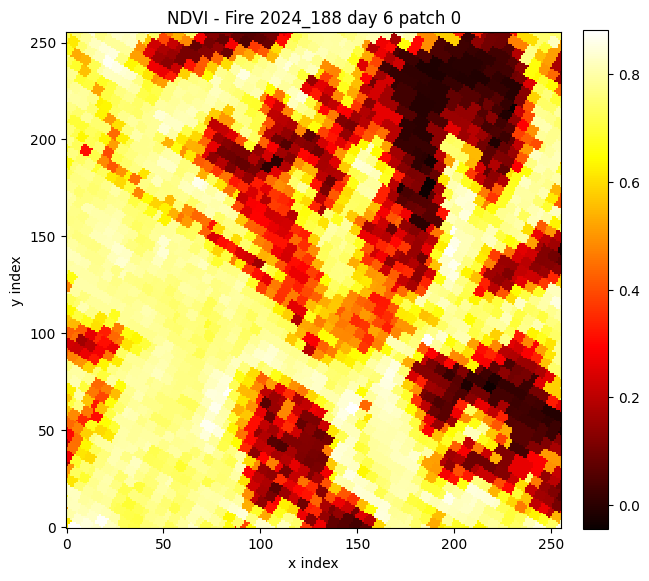

In [149]:
grid_from_h5 = get_h5_dataset(f"{H5_OUTPUT_FOLDER}/fire_2024_188.h5", "days/day_006/features/ndvi")
visualize_grid_values_by_image(grid_from_h5, feature='NDVI', fire_ID='2024_188', fireday=6, patch=0)

# Samples Visualization

In [60]:
def visualize_h5_sample(h5_path, day_key, dynamic_features=None, static_features=None, cmap='turbo'):
    """
    Plots a grid of specified dynamic and static features from the H5 file.
    
    Args:
        h5_path (str): Path to the HDF5 file.
        day_key (str): The day group to pull dynamic features from (e.g., 'day_001').
        dynamic_features (list): List of feature names in days/day_XXX/features/
        static_features (list): List of feature names in static_features/
        cmap (str or Colormap): Matplotlib colormap to use.
    """
    if dynamic_features is None: dynamic_features = []
    if static_features is None: static_features = []
    
    total_plots = len(dynamic_features) + len(static_features)
    if total_plots == 0:
        print("No features selected for visualization.")
        return
        
    # Automatically determine grid size
    cols = min(3, total_plots)
    rows = math.ceil(total_plots / cols)
    
    # Create the figure
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    
    # Standardize axes to a 1D list for easy iteration
    if total_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    with h5py.File(h5_path, 'r') as f:
        plot_idx = 0
        
        # Plot Dynamic Features
        for feat in dynamic_features:
            ax = axes[plot_idx]
            path = f'days/{day_key}/features/{feat}'
            if path in f:
                data = f[path][:]
                
                if feat == 'cumuarea' or feat == 'firearea': # Binarize cumuarea and firearea
                    data = np.where(data > 0, 1, 0)
                    im = ax.imshow(data, cmap='hot', origin='lower', interpolation='none')
                # elif feat not in ['ndvi', 'evi']:
                #     data = np.where(data < 0, np.nan, data)
                #     im = ax.imshow(data, cmap=cmap, origin='lower', interpolation='none')
                else:
                    im = ax.imshow(data, cmap=cmap, origin='lower', interpolation='none')
                
                ax.set_title(f"Dynamic: {feat}\n({day_key})")
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            else:
                ax.set_title(f"{feat} missing")
                ax.axis('off')
            plot_idx += 1
            
        # Plot Static Features
        for feat in static_features:
            ax = axes[plot_idx]
            path = f'static_features/{feat}'
            if path in f:
                data = f[path][:]
                # data = np.where(data == -9999, np.nan, data)
                # data = np.where(data < 0, np.nan, data)
                
                im = ax.imshow(data, cmap=cmap, origin='lower', interpolation='none')
                ax.set_title(f"Static: {feat}")
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            else:
                ax.set_title(f"{feat} missing")
                ax.axis('off')
            plot_idx += 1
            
        # Hide any leftover empty subplots
        for i in range(plot_idx, len(axes)):
            axes[i].axis('off')
            
    plt.tight_layout()
    plt.show()

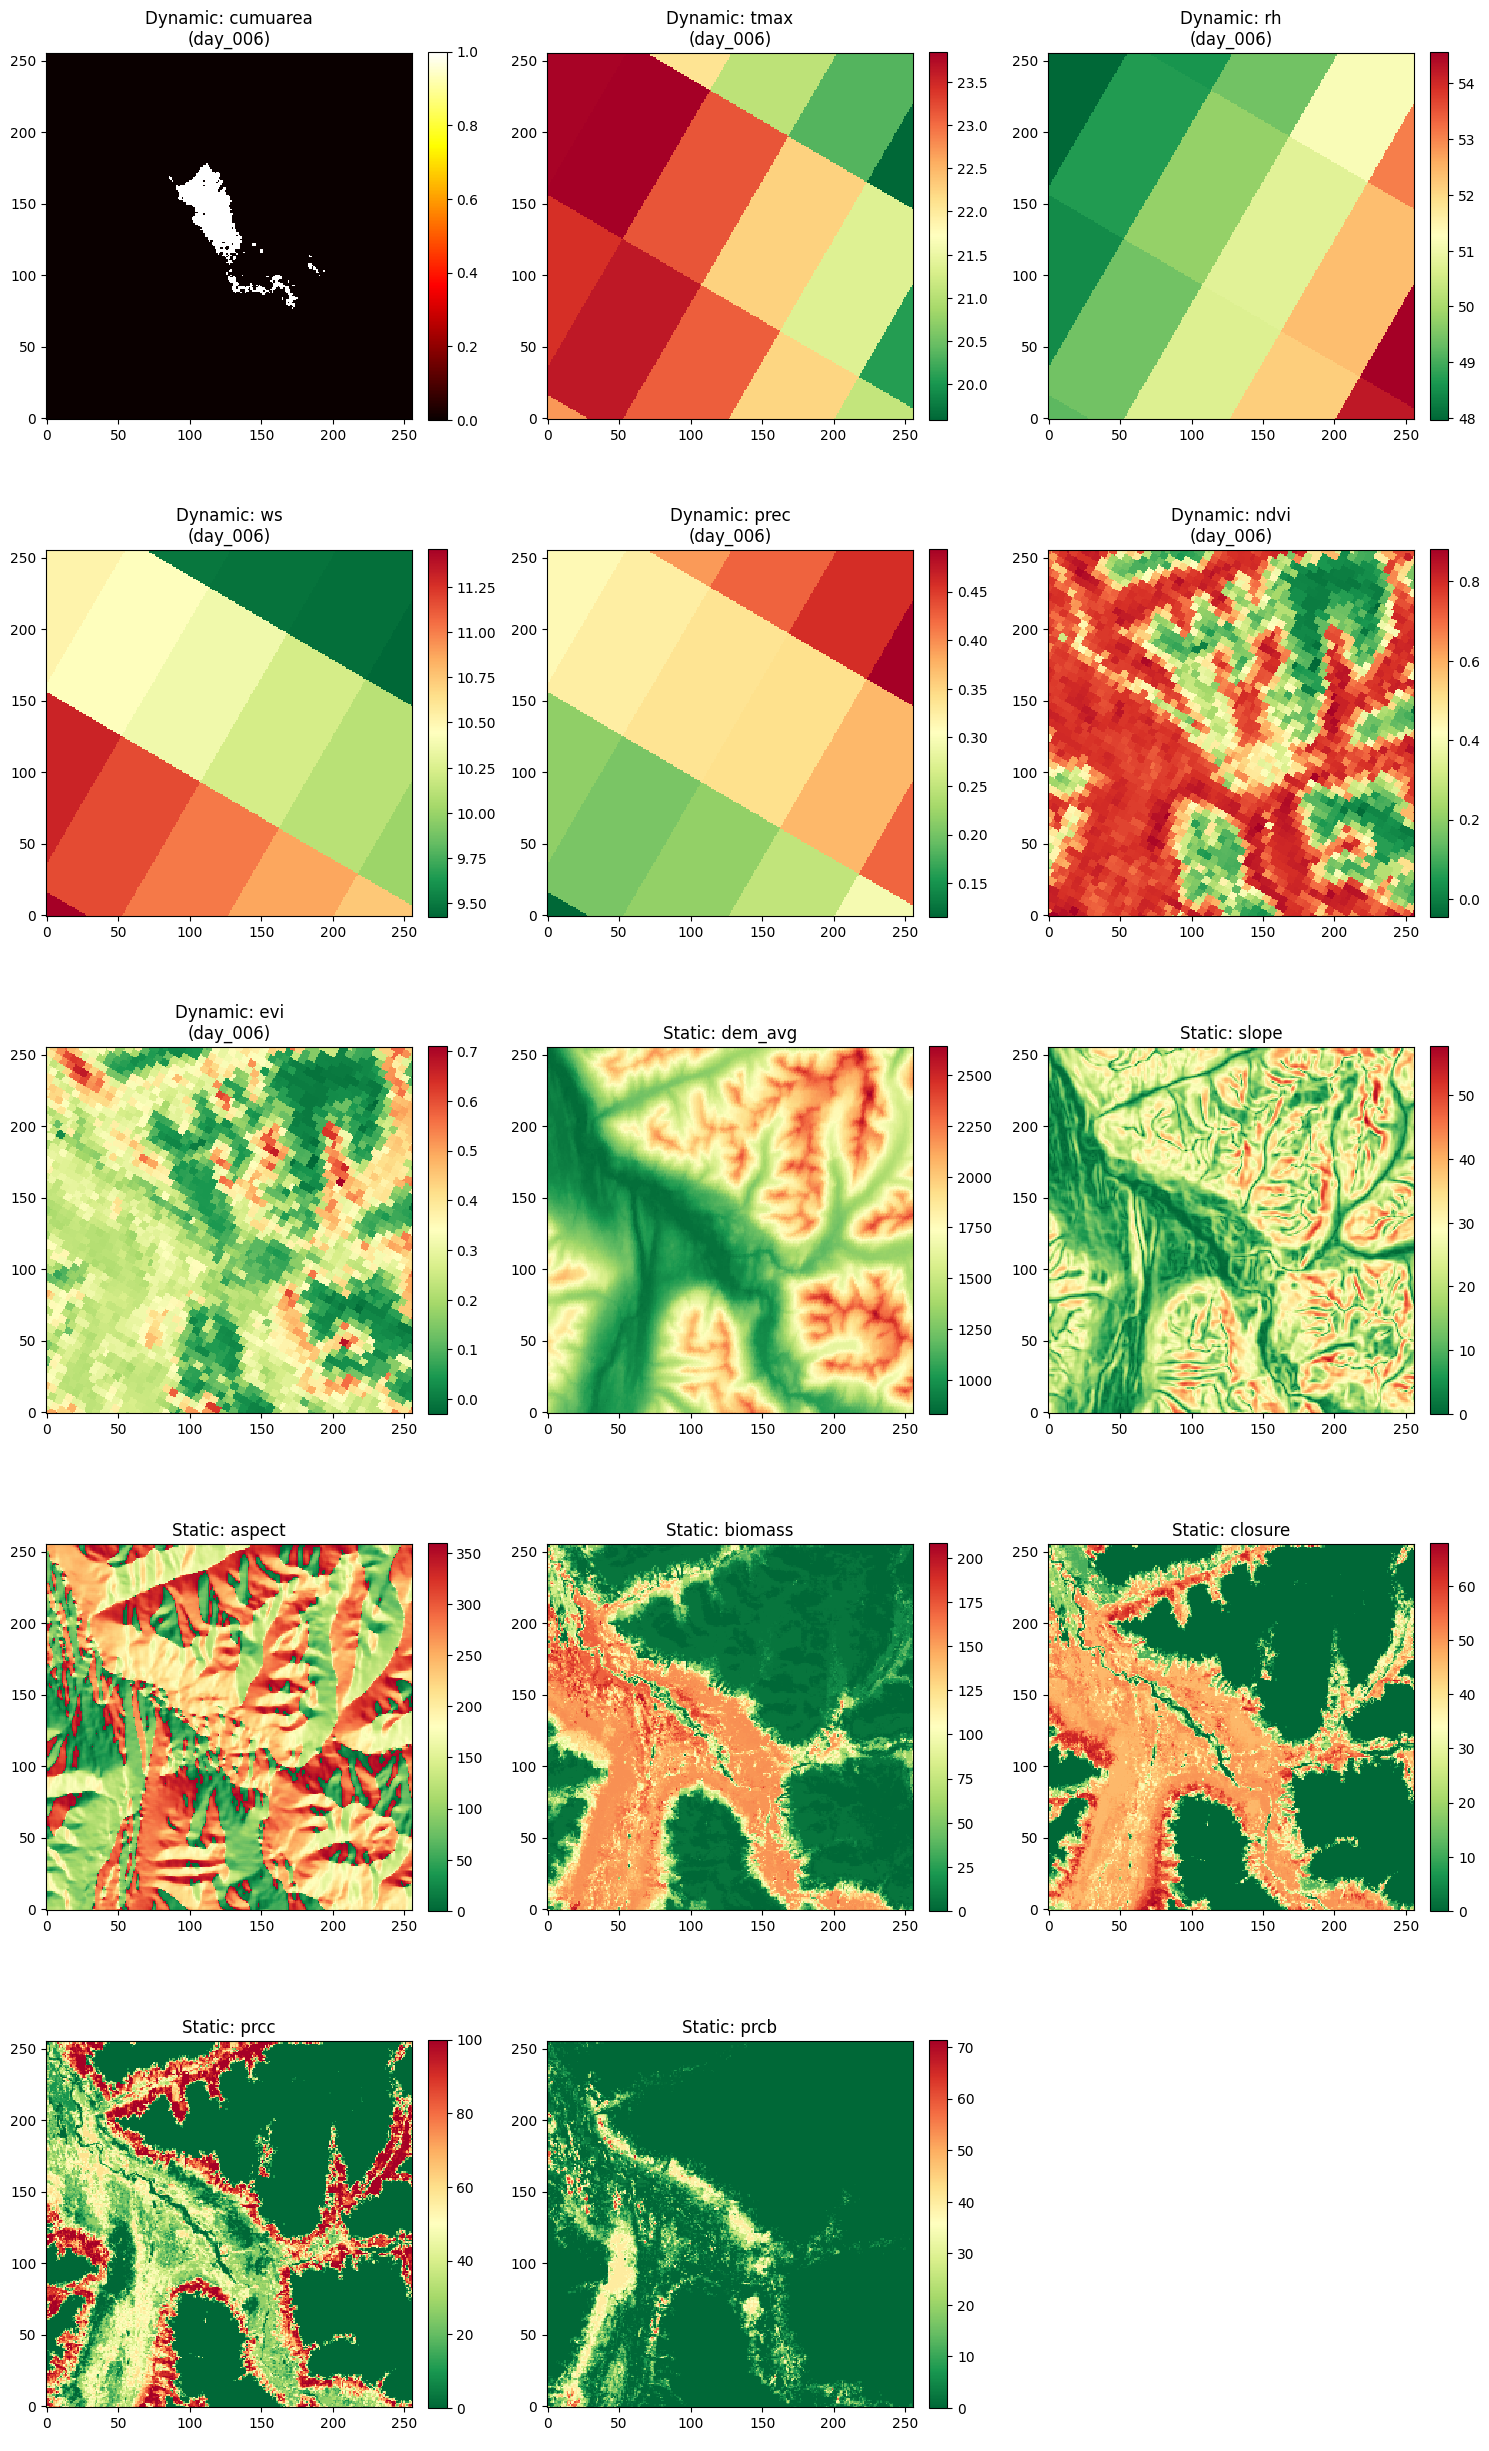

In [61]:
h5_test_file = "fires_H5/fire_2024_188.h5"

dynamic_vars = ['cumuarea', 'tmax', 'rh', 'ws', 'prec', 'ndvi', 'evi']
static_vars = ['dem_avg', 'slope', 'aspect', 'biomass', 'closure', 'prcc', 'prcb']

# Plot
visualize_h5_sample(
    h5_path=h5_test_file, 
    day_key="day_006", 
    dynamic_features=dynamic_vars, 
    static_features=static_vars,
    cmap="RdYlGn_r"
)

In [65]:
def analyze_pipeline_stats(json_path, h5_folder):
    """
    Reads processing times from a JSON log and calculates total/average times.
    """
    
    print(f"{'='*40}\nTIMING STATISTICS\n{'='*40}")
    
    try:
        with open(json_path, 'r') as f:
            time_data = json.load(f)
            
        timing_records = []
        # Loop through the dictionary and sum the steps for each fire
        for fire_id, steps in time_data.items():
            total_seconds = sum(steps.values())
            timing_records.append({
                'Fire_ID': fire_id,
                'Total_Seconds': round(total_seconds, 2),
                'Total_Minutes': round(total_seconds / 60, 2)
            })
            
        time_df = pd.DataFrame(timing_records)
        avg_sec = time_df['Total_Seconds'].mean()
        avg_min = time_df['Total_Minutes'].mean()
        
        display(time_df)
        print(f"\nAverage Processing Time per Fire: {avg_sec:.2f} seconds ({avg_min:.2f} minutes)")
        
    except FileNotFoundError:
        print(f"Could not find {json_path}. Skipping time analysis.")


    # HDF5 File Size Analysis
    print(f"\n{'='*40}\nFILE SIZE STATISTICS\n{'='*40}")
    
    folder_path = Path(h5_folder)
    size_records = []
    
    # Find all .h5 files and get their sizes in Megabytes
    for h5_file in folder_path.glob('*.h5'):
        # st_size returns bytes (divide by 1024 twice for MB)
        size_mb = h5_file.stat().st_size / (1024 * 1024)
        size_records.append({
            'File_Name': h5_file.name,
            'Size_MB': round(size_mb, 2)
        })
        
    if size_records:
        size_df = pd.DataFrame(size_records)
        avg_size = size_df['Size_MB'].mean()
        total_size = size_df['Size_MB'].sum()
        
        display(size_df)
        print(f"\nAverage File Size: {avg_size:.2f} MB")
        print(f"Total Folder Size: {total_size:.2f} MB")
    else:
        print(f"No .h5 files found in {h5_folder}.")
        
    return time_df, size_df

In [68]:
H5_OUTPUT_FOLDER = 'fires_H5'

timing_log_path = "fires_H5/processing_times_cmp_v3.json"

times_df, sizes_df = analyze_pipeline_stats(timing_log_path, H5_OUTPUT_FOLDER)

TIMING STATISTICS


,Fire_ID,Total_Seconds,Total_Minutes
0,2024_188,84.13,1.40
1,2024_306,132.75,2.21
2,2024_486,33.15,0.55
3,2024_545,191.63,3.19
4,2024_560,15.37,0.26



Average Processing Time per Fire: 91.41 seconds (1.52 minutes)

FILE SIZE STATISTICS


,File_Name,Size_MB
0,fire_2024_188.h5,59.84
1,fire_2024_188_temp.h5,12.40
2,fire_2024_306.h5,11.72
3,fire_2024_486.h5,4.68
4,fire_2024_545.h5,502.48
5,fire_2024_560.h5,24.31



Average File Size: 102.57 MB
Total Folder Size: 615.43 MB


In [69]:
def get_detailed_stats(json_path, h5_folder):
    
    # Load Timing Data from JSON
    with open(json_path, "r") as f:
        data = json.load(f)
    
    df = pd.DataFrame.from_dict(data, orient='index')
    df.index.name = 'fire_id'
    
    # Calculate Totals
    df['total_sec'] = df.sum(axis=1)
    df['total_min'] = df['total_sec'] / 60
    
    # Get File Sizes from the H5 folder
    folder = Path(h5_folder)
    file_sizes = {}
    
    for h5_file in folder.glob("*.h5"):
        # Extract ID (e.g., '2024_188' from 'fire_2024_188.h5')
        fire_id = h5_file.stem.replace("fire_", "")
        # Convert bytes to Megabytes
        file_sizes[fire_id] = h5_file.stat().st_size / (1024 * 1024)
    
    df['file_size_mb'] = df.index.map(file_sizes)
    
    df = df.reset_index().round(2)
    
    return df

In [71]:
timing_log_path = f"{H5_OUTPUT_FOLDER}/processing_times.json"

df_final_stats = get_detailed_stats(timing_log_path, H5_OUTPUT_FOLDER)

df_final_stats

,fire_id,file_creation,weather,topography,scanfi,vegetation,total_sec,total_min,file_size_mb
0,2024_188,54.70,17.23,0.74,0.78,13.24,86.70,1.44,59.84
1,2024_306,90.60,24.47,1.03,0.81,20.88,137.79,2.30,11.72
2,2024_486,16.89,11.12,0.89,0.81,5.03,34.74,0.58,4.68
3,2024_545,84.70,58.06,3.71,3.22,51.37,201.06,3.35,502.48
4,2024_560,4.07,5.28,2.29,2.23,3.05,16.92,0.28,24.31


# Satellite images

In [86]:
# Source https://github.com/RolnickLab/SatBird/blob/release/data_processing/satellite/download_rasters_from_planetary_computer.py

In [72]:
import os
from shapely.geometry import box
from datetime import datetime, timedelta
import stackstac
import planetary_computer
import pystac_client
from pystac.extensions.eo import EOExtension as eo
from pathlib import Path
import rasterio
import xarray as xr
from rioxarray.merge import merge_arrays
import rasterio
from rasterio import windows, features, warp
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import from_origin
from PIL import Image
from shapely import wkt
from shapely.geometry import mapping, box, shape
from shapely.ops import transform as shapely_transform
from retrying import retry
import argparse
from datetime import date
from PIL import Image
from shapely.geometry import box
import pandas as pd
from shapely.geometry import box
from datetime import datetime, timedelta

In [73]:
NUM_RETRIES = 5
WAIT_INTERVAL = 1  # seconds

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    # modifier=planetary_computer.sign_inplace,
)

In [74]:
def get_multiband_geotiff_image_m(file_path, area_of_interest, target_width=800, as_rgb=False):
    """
    Reads a single multi-band GeoTIFF, crops to AOI, and returns a PIL Image.
    BANDS order in file: [B02, B03, B04, B08] 
    (Blue=1, Green=2, Red=3, NIR=4)
    """
    aoi_bounds = features.bounds(area_of_interest)
    print(aoi_bounds)

    with rasterio.open(file_path) as ds:
        # Coordinate Translation
        aoi_window = windows.from_bounds(*aoi_bounds, transform=ds.transform)
        
        if as_rgb:
            # Sentinel-2 True Color is Red (B04), Green (B03), Blue (B02)
            band_data = ds.read([3, 2, 1], window=aoi_window)
            # Rearrange from (3, H, W) to (H, W, 3) for PIL
            final_array = np.transpose(band_data, (1, 2, 0))
            print(final_array.shape)
        else:
            # Default to NIR (B08) which is index 4, or change as needed
            final_array = ds.read(4, window=aoi_window)
            print(final_array.shape)

        # Normalize 16-bit to 8-bit
        # We check the max of the slice
        if final_array.max() > 255:
            # Using 4000 as a divisor for clear visualization
            final_array = (np.clip(final_array / 4000, 0, 1) * 255).astype(np.uint8)
        else:
            final_array = final_array.astype(np.uint8)

    # Create Image
    img = Image.fromarray(final_array)
    
    # Resize
    aspect = img.size[0] / img.size[1]
    target_height = int(target_width / aspect)
    return img.resize((target_width, target_height), Image.Resampling.BILINEAR)

In [24]:
# Sources https://towardsdatascience.com/quantifying-burned-areas-from-wildfires-using-satellite-imagery-97683d025767/
# https://towardsdatascience.com/satellites-can-see-invisible-lava-flows-and-active-wildires-but-how-python-371915464d1c/

In [75]:
def get_h5_bounds_3347(h5_path):
    """
    Reads the exact theoretical grid from the H5 using pre-existing 
    easting/northing arrays for perfect Stackstac alignment.
    """
    with h5py.File(h5_path, 'r') as f:
        # For STAC API spatial search (Strictly EPSG:4326)
        lons = f['geometry/theoretical_lon'][:]
        lats = f['geometry/theoretical_lat'][:]
        
        # For Stackstac pixel cropping (Strictly EPSG:3347)
        eastings = f['geometry/theoretical_easting'][:]
        northings = f['geometry/theoretical_northing'][:]
        
    min_lon, max_lon = lons.min(), lons.max()
    min_lat, max_lat = lats.min(), lats.max()
    
    min_x, max_x = eastings.min(), eastings.max()
    min_y, max_y = northings.min(), northings.max()
    
    return (min_x, min_y, max_x, max_y), min_lon, max_lon, min_lat, max_lat

In [76]:
def fetch_s2_array_in_memory_v3(items, bbox_3347, bands, pixel_size=90, max_retries=3, backoff_factor=2):
    """
    Downloads a stack of Sentinel-2 images and mosaics them across TIME.
    Returns the final image and a dictionary of the physical cloud cover footprint.
    Includes retry logic for network stability.
    """
    
    if not items: 
        return None, {}
    
    items.sort(key=lambda x: (x.datetime.date(), -x.properties.get('eo:cloud_cover', 100)), reverse=False)
        
    try:
        signed_items = [planetary_computer.sign(i) for i in items]
    except Exception as e:
        print(f"Failed to sign items with Planetary Computer: {e}")
        return None, {}

    stack = stackstac.stack(
        signed_items,
        epsg=3347,
        resolution=pixel_size,
        bounds=bbox_3347, 
        assets=bands,
        sortby_date=False, 
        fill_value=0 
    )

    cc_to_date = {}
    for i in range(stack.sizes['time']):
        exact_cc = float(stack.coords["eo:cloud_cover"].values[i])
        date_str = str(stack.coords["time"].values[i])[:10] 
        cc_to_date[exact_cc] = date_str

    valid_stack = stack.where(stack != 0)
    processed = stackstac.mosaic(valid_stack, dim="time").squeeze()

    cc_da = stack.coords["eo:cloud_cover"].astype(float)
    cc_stack = cc_da.broadcast_like(valid_stack.isel(band=0))
    valid_cc_stack = cc_stack.where(valid_stack.isel(band=0).notnull())
    cc_mosaic = stackstac.mosaic(valid_cc_stack, dim="time")

    # Retry logic
    processed_computed = None
    cc_computed = None
    
    for attempt in range(max_retries):
        try:
            processed_computed, cc_computed = dask.compute(processed, cc_mosaic)
            break
            
        except Exception as e:
            if attempt < max_retries - 1:
                sleep_time = backoff_factor ** attempt
                print(f"Network error on compute (Attempt {attempt + 1}/{max_retries}): {e}")
                print(f"Retrying in {sleep_time} seconds...")
                time.sleep(sleep_time)
            else:
                print(f"Final attempt failed after {max_retries} retries: {e}")
                raise
    
    # Final cleanup for the image
    processed_computed = processed_computed.fillna(0).astype("uint16")
    
    # Calculate the Statistics
    cc_values = cc_computed.values.flatten()
    cc_values = cc_values[~np.isnan(cc_values)]
    
    cc_stats = []
    total_valid_pixels = len(cc_values)
    
    if total_valid_pixels > 0:
        unique_cc, counts = np.unique(cc_values, return_counts=True)
        for cc, count in zip(unique_cc, counts):
            percentage = (count / total_valid_pixels) * 100
            date_used = cc_to_date.get(cc, "Unknown Date")
            entry = {
                "pixels_pct": round(percentage, 2),
                "cloud_cover_pct": round(cc, 2),
                "acquisition_date": date_used  # In ISO 8601 format: YYYY-MM-DD
            }
            cc_stats.append(entry)
            
    return processed_computed, cc_stats

In [77]:
def run_s2_h5_pipeline_v2(h5_path, catalog, bands=["B02", "B03", "B04", "B08", "B11", "B12"], temporal_buffer_days=5, filling_buffer_days=2):
    """
    Main pipeline that uses a (filling_buffer_days)-day rolling window to ensure no black gaps.
    """

    bbox_3347, min_lon, max_lon, min_lat, max_lat = get_h5_bounds_3347(h5_path)
    
    with h5py.File(h5_path, 'a') as f:
        
        days_grp = f['days']
        day_keys = sorted(days_grp.keys())
        fire_year = int(f.attrs['year'])
        
        buffer = 1
        search_bbox = [min_lon - buffer, min_lat - buffer, max_lon + buffer, max_lat + buffer]
        
        # Search the whole fire period
        start_date = datetime(fire_year, 1, 1) + timedelta(days=int(days_grp[day_keys[0]].attrs['DOB']) - 1 - temporal_buffer_days)
        end_date = datetime(fire_year, 1, 1) + timedelta(days=int(days_grp[day_keys[-1]].attrs['DOB']) - 1 + temporal_buffer_days)
        
        search = catalog.search(collections=["sentinel-2-l2a"], bbox=search_bbox, datetime=f"{start_date.date()}/{end_date.date()}")
        all_items = list(search.items())

        cached_date_used = None
        cached_array = None

        for day_key in tqdm(day_keys, desc=f"Processing Days for {h5_path.name}"):
            
            day_grp = days_grp[day_key]
            sat_grp = day_grp.require_group('satellite')
            
            current_doy = int(day_grp.attrs['DOB'])
            target_date_obj = (datetime(fire_year, 1, 1) + timedelta(days=current_doy - 1)).date()
            
            # Instead of looking for target_date_obj only, take a (filling_buffer_days+1)-day window 
            # (Target day + filling_buffer_days days of 'history' to fill holes)
            lookback_date = target_date_obj - timedelta(days=filling_buffer_days)
            rolling_items = [
                i for i in all_items 
                if lookback_date <= i.datetime.date() <= target_date_obj
            ]

            if not rolling_items:
                continue

            # Date tracking for Cache
            # Track the 'target_date' to know when to update the cache
            if target_date_obj != cached_date_used:
                cached_array, stats = fetch_s2_array_in_memory_v3(rolling_items, bbox_3347, bands)
                cached_date_used = target_date_obj

                sat_grp.attrs["cloud_cover_stats"] = json.dumps(stats)

            for i, band_name in enumerate(bands):
                
                band_data = cached_array[i, :, :].values 
                dset = sat_grp.require_dataset(f"s2_{band_name}", data=band_data, shape=band_data.shape, dtype=band_data.dtype, compression="lzf")

In [ ]:
h5_files = list(Path(H5_OUTPUT_FOLDER).glob("*.h5"))
selected_bands = [f"B{i:02}" for i in range(1, 13) if i != 10]
    
for h5_path in h5_files:
        
    run_s2_h5_pipeline_v2(h5_path, catalog, bands=selected_bands, temporal_buffer_days=5, filling_buffer_days=2)

In [79]:
with h5py.File(f"{H5_OUTPUT_FOLDER}/fire_2024_188.h5", "r") as f:

    dset = f["days/day_007/satellite"]
    cc_stats = json.loads(dset.attrs["cloud_cover_stats"])
    print(cc_stats)
    print('Number of tiles: ', len(cc_stats))
    print(f"{cc_stats[0]['pixels_pct']}%", f"{cc_stats[0]['cloud_cover_pct']}%", cc_stats[0]['acquisition_date'])

[{'pixels_pct': 82.64, 'cloud_cover_pct': 30.05, 'acquisition_date': '2024-07-22'}, {'pixels_pct': 17.36, 'cloud_cover_pct': 32.06, 'acquisition_date': '2024-07-22'}]
Number of tiles:  2
82.64% 30.05% 2024-07-22


In [80]:
def plot_h5_s2_composites(h5_path, day_key, gain=2.5):
    """
    Reads Sentinel-2 bands from H5 for a specific day and creates
    Natural Color, False Color (NIR), and SWIR composites.
    """
    with h5py.File(h5_path, 'r') as f:
        # Navigate to the satellite group for the chosen day
        sat_path = f"days/{day_key}/satellite"
        if sat_path not in f:
            print(f"Error: Path {sat_path} not found in H5.")
            return
        
        sat = f[sat_path]
        
        # Read the bands directly from the H5 datasets
        # Sentinel-2 Mapping: B02=Blue, B03=Green, B04=Red, B08=NIR, B11=SWIR1, B12=SWIR2
        # We divide by 10000 to convert S2 DN to reflectance (0-1 range)
        def get_band(name):
            data = sat[f"s2_{name}"][:] # Load the 2D array
            return np.clip(data * gain / 10000, 0, 1)

        blue_n  = get_band("B02")
        green_n = get_band("B03")
        red_n   = get_band("B04")
        nir_n   = get_band("B08")
        swir1_n = get_band("B11")
        swir2_n = get_band("B12")

    # Stack the processed arrays into RGB composites
    # Natural Color: Red, Green, Blue
    rgb_composite = np.dstack((red_n, green_n, blue_n))
    
    # False Color Infrared: NIR, Red, Green
    nir_composite = np.dstack((nir_n, red_n, green_n))
    
    # Shortwave Infrared: SWIR2, SWIR1, NIR (Great for seeing through smoke/burn scars)
    swir_composite = np.dstack((swir2_n, swir1_n, nir_n))

    # Plot
    plt.figure(figsize=(24, 8), facecolor='white')

    # RGB
    plt.subplot(131)
    plt.title('True Color (B4, B3, B2)', fontsize=15, fontweight='bold')
    plt.imshow(rgb_composite)
    plt.axis('off')

    # NIR
    plt.subplot(132)
    plt.title('Color Infrared (B8, B4, B3)', fontsize=15, fontweight='bold')
    plt.imshow(nir_composite)
    plt.axis('off')

    # SWIR
    plt.subplot(133)
    plt.title('SWIR Fire/Burn (B12, B11, B8)', fontsize=15, fontweight='bold')
    plt.imshow(swir_composite)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

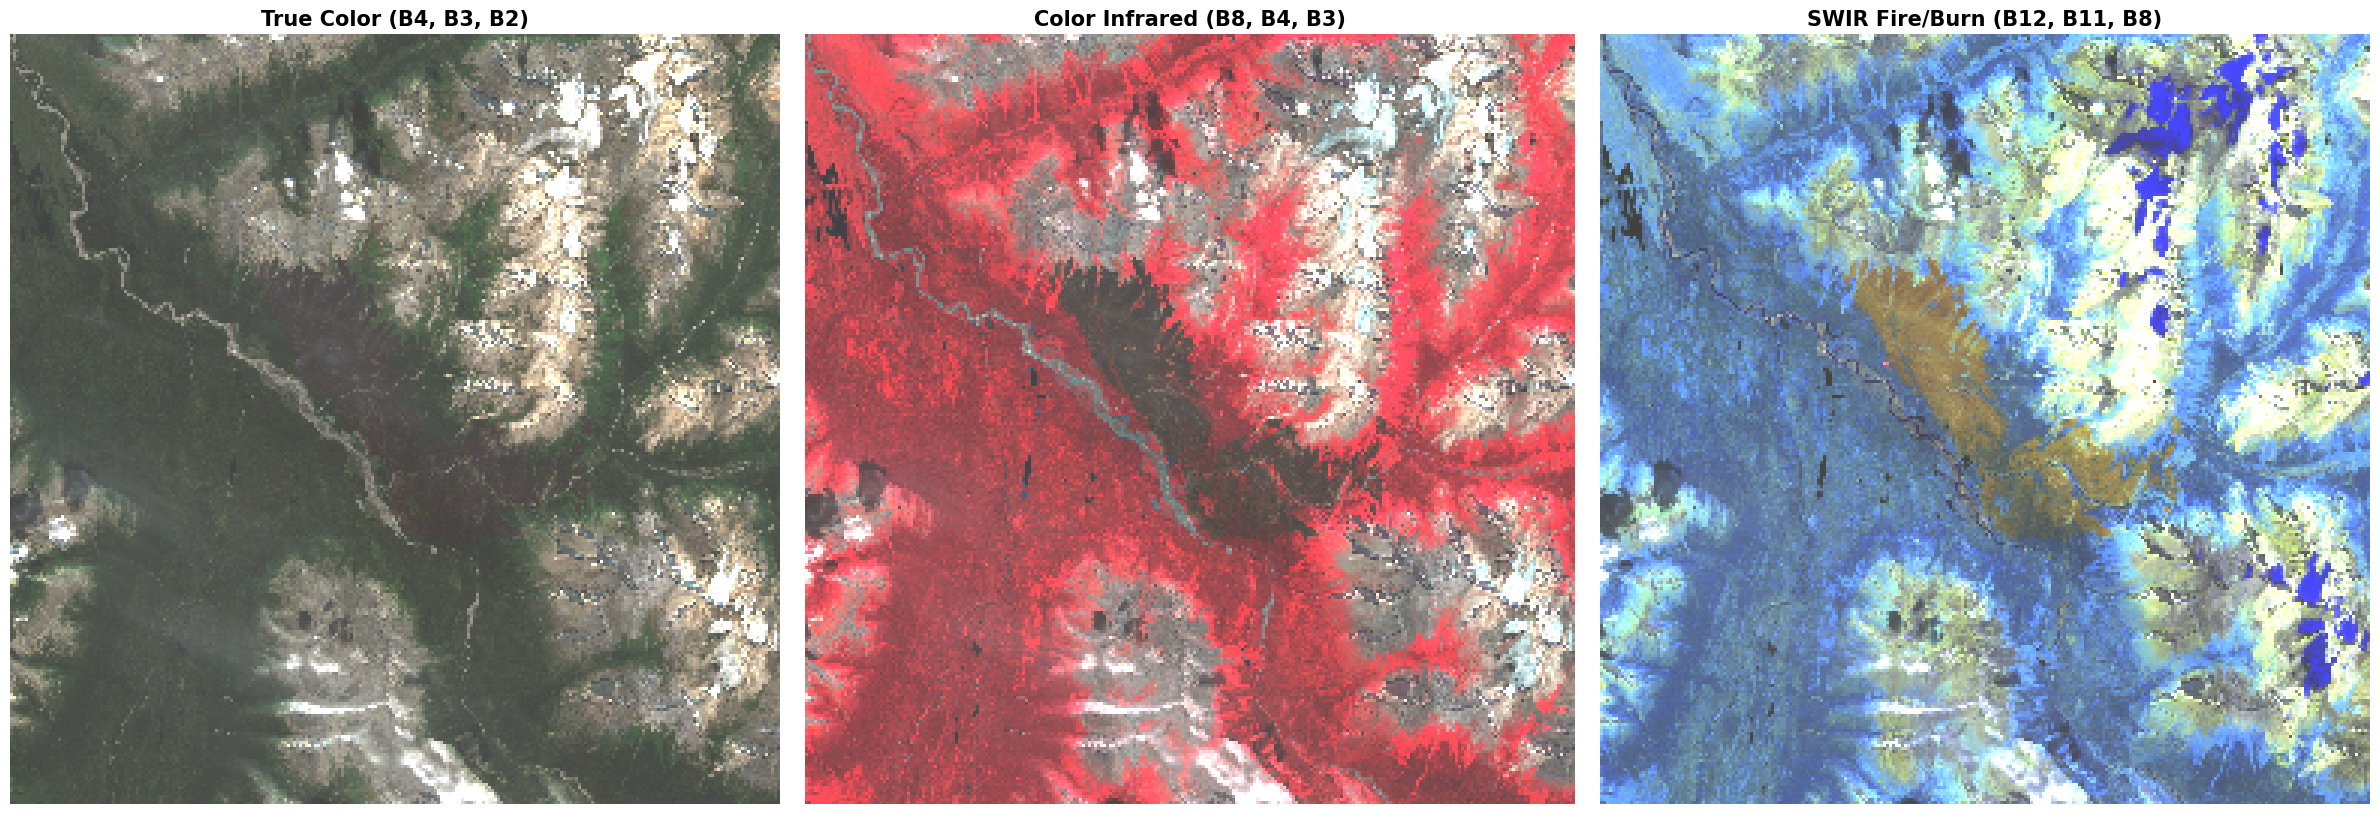

In [81]:
# Example
h5_test_file = f"{H5_OUTPUT_FOLDER}/fire_2024_188.h5"
# plot_h5_s2_composites(h5_test_file, day_key="day_007", gain=2.5)
plot_h5_s2_composites(h5_test_file, day_key="day_022", gain=2.5)

# File Structure 

In [82]:
def show_h5_architecture(h5_path):
    """
    Prints the architecture of the H5 file including Group Attributes (noon_utc, dob, etc.).
    """
    print(f"\n📂 H5 ARCHITECTURE: {h5_path}")
    print("="*60)

    with h5py.File(h5_path, 'r') as f:
        # 1. Global Attributes
        if f.attrs:
            print("Global Attributes:")
            for k, v in f.attrs.items():
                print(f"    ├── {k}: {v}")
            print("")

        first_day_key = sorted(list(f['days'].keys()))[0] if 'days' in f else None
        first_day_key = 'day_007'

        def walk_structure(name, obj):
            parts = name.split('/')
            
            # Only show day_001 structure
            if parts[0] == 'days' and len(parts) > 1:
                if parts[1].startswith('day_') and parts[1] != first_day_key:
                    return 

            indent = "    " * (len(parts) - 1)
            
            if isinstance(obj, h5py.Group):
                print(f"{indent}📁 {parts[-1]}/")
                # Check for attributes inside the Group
                if obj.attrs:
                    for attr_name, attr_val in obj.attrs.items():
                        print(f"{indent}    🏷️ {attr_name}: {attr_val}")
            else:
                # Show Dataset
                print(f"{indent}📊 {parts[-1]:<20} [Shape: {obj.shape}, Type: {obj.dtype}]")

        f.visititems(walk_structure)
    
    print("="*60)
    print("Note: Only the first fire-day is shown. '🏷️' icons indicate attributes (metadata).\n")

In [83]:
h5_test_file = f"{H5_OUTPUT_FOLDER}/fire_2024_188.h5"
show_h5_architecture(h5_test_file)


📂 H5 ARCHITECTURE: ../fires_H5/fire_2024_188.h5
Global Attributes:
    ├── deg_crs: EPSG:4269
    ├── fire_id: 2024_188
    ├── meter_crs: EPSG:3347
    ├── pixel_size: 90
    ├── year: 2024

📁 days/
    📁 day_007/
        🏷️ DOB: 204
        🏷️ end_utc: 2024-07-23T07:00:00
        🏷️ fireday: 7
        🏷️ month: 7
        🏷️ noon_utc: 2024-07-22T19:00:00
        🏷️ start_utc: 2024-07-22T07:00:00
        📁 features/
            📊 cumuarea             [Shape: (256, 256), Type: float32]
            📊 evi                  [Shape: (256, 256), Type: float64]
            📊 firearea             [Shape: (256, 256), Type: float32]
            📊 ndvi                 [Shape: (256, 256), Type: float64]
            📊 prec                 [Shape: (256, 256), Type: float32]
            📊 rh                   [Shape: (256, 256), Type: float32]
            📊 tmax                 [Shape: (256, 256), Type: float32]
            📊 ws                   [Shape: (256, 256), Type: float32]
        📁 observed_